# Análisis de Niveles de Obesidad mediante Métodos de Ciencia de Datos
## Metodología CRISP-DM

**Dataset:** Estimation of Obesity Levels Based On Eating Habits and Physical Condition
**Fuente:** UCI Machine Learning Repository
**Registros:** 2.111 · **Atributos:** 17

---
**Alumno:** Dante Gil Zenteno
**Docente:** Dr. Mauricio Sepúlveda
**Asignatura:** Taller de Aplicaciones — Magíster en Data Science, Facultad de Ingeniería

---
### Resumen del enfoque

| Fase CRISP-DM | Contenido |
|---|---|
| Comprensión del negocio | Definición del problema de extracción de conocimiento |
| Comprensión de los datos | Inspección, estadísticas, calidad |
| Preparación de los datos | Limpieza, codificación, escalado |
| Modelamiento | Agrupamiento · Clasificación · Asociación FP-Growth |
| Evaluación | Métricas por modelo, selección del mejor, mejoras futuras |
| Experimentos | PCA · TruncatedSVD · Ingeniería de características (5 atributos) |
| Presentación | Insumos para PPT de 15 diapositivas |

> **Versión 3** — conserva las iteraciones 1 (base) y 2 (PCA, TruncatedSVD,
> ingeniería de características inicial, XGBoost, bibliografía) y agrega la
> **Iteración 3**: comparación justificada de algoritmos de clustering
> (K-Means vs GMM vs Agglomerative vs DBSCAN), SVM como clasificador adicional,
> tratamiento ordinal de CAEC/CALC, ingeniería de características ampliada
> (interacción FAF×FAVC), validación cruzada estratificada k=5 y optimización
> de hiperparámetros con búsqueda aleatoria (scoring F1 macro).


## 00 · Configuración de Visualización de Outputs

Para evitar el mensaje *"Output is truncated"* del notebook, se configura pandas
para mostrar todas las columnas y filas relevantes. Los reportes extensos se
convierten en DataFrames y, cuando corresponde, se exportan como CSV a `outputs/`.


In [1]:
import pandas as pd
import numpy as np
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 0)
pd.set_option('display.expand_frame_repr', False)
np.set_printoptions(threshold=np.inf)


def mostrar_completo(df_, filas=200):
    """Muestra un DataFrame completo sin truncamiento de filas ni columnas."""
    with pd.option_context(
        'display.max_rows', filas,
        'display.max_columns', None,
        'display.max_colwidth', None,
        'display.width', 0,
        'display.expand_frame_repr', False,
    ):
        display(df_)


print('Visualización de pandas configurada — sin outputs truncados.')


Visualización de pandas configurada — sin outputs truncados.


## 01 · Importación de Librerías

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (LabelEncoder, StandardScaler,
                                   OrdinalEncoder, OneHotEncoder)
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              calinski_harabasz_score, accuracy_score,
                              precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_validate, RandomizedSearchCV)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import clone
from xgboost import XGBClassifier
import joblib

from mlxtend.frequent_patterns import fpgrowth, association_rules

os.makedirs('outputs', exist_ok=True)
os.makedirs('models', exist_ok=True)

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titlesize'] = 13
sns.set_style('white')

RANDOM_STATE = 42
RUTA_DATOS = 'data/ObesityDataSet_raw_and_data_sinthetic.csv'

# ─── Paleta de diseño coherente con la PPT (data storytelling, Cole Knaflic) ───
AZUL    = '#2563EB'   # principal / métricas / foco
MORADO  = '#7C3AED'   # iteraciones / experimentos / reducción dimensional
VERDE   = '#16A34A'   # positivo / mejora / modelo ganador
NARANJA = '#F97316'   # advertencia / degradación leve
ROJO    = '#DC2626'   # riesgo / peor resultado
TINTA   = '#0F172A'   # texto / títulos
GRIS    = '#94A3B8'   # contexto / secundario / lo no destacado
GRIS_CL = '#CBD5E1'   # bordes / grillas suaves

# Paleta categórica controlada para 4 clusters
COLORES_CLUSTERS = [AZUL, MORADO, NARANJA, VERDE]

print('Librerías cargadas correctamente.')


Librerías cargadas correctamente.


## 02 · Carga de Datos
### CRISP-DM — Fase 1: Comprensión del Negocio

**Problema:** Predecir y agrupar niveles de obesidad a partir de hábitos alimentarios,
actividad física y características personales de individuos de México, Perú y Colombia.

**Preguntas guía:**
- ¿Existen grupos de personas con perfiles similares de riesgo?
- ¿Qué algoritmo predice mejor el nivel de obesidad?
- ¿Qué combinaciones de hábitos se asocian frecuentemente a ciertos niveles de obesidad?


In [3]:
df = pd.read_csv(RUTA_DATOS)
print(f'Dataset cargado exitosamente.')
print(f'  Registros  : {df.shape[0]}')
print(f'  Atributos  : {df.shape[1]}')
print(f'  Variable objetivo: {df.columns[-1]}')
df.head()


Dataset cargado exitosamente.
  Registros  : 2111
  Atributos  : 17
  Variable objetivo: NObeyesdad


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## 03 · Comprensión de los Datos
### CRISP-DM — Fase 2: Comprensión de los Datos


In [4]:
print('=== TIPOS DE DATOS ===')
print(df.dtypes)
print()
print('=== VALORES NULOS ===')
print(df.isnull().sum())
print()
print('=== DUPLICADOS ===')
print(f'Filas duplicadas: {df.duplicated().sum()}')
print()
print('=== ESTADÍSTICAS DESCRIPTIVAS ===')
df.describe().round(2)


=== TIPOS DE DATOS ===
Gender                                str
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight        str
FAVC                                  str
FCVC                              float64
NCP                               float64
CAEC                                  str
SMOKE                                 str
CH2O                              float64
SCC                                   str
FAF                               float64
TUE                               float64
CALC                                  str
MTRANS                                str
NObeyesdad                            str
dtype: object

=== VALORES NULOS ===
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC      

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00
mean,24.31,1.70,86.59,2.42,2.69,2.01,1.01,0.66
std,6.35,0.09,26.19,0.53,0.78,0.61,0.85,0.61
min,14.00,1.45,39.00,1.00,1.00,1.00,0.00,0.00
25%,19.95,1.63,65.47,2.00,2.66,1.58,0.12,0.00
50%,22.78,1.70,83.00,2.39,3.00,2.00,1.00,0.63
75%,26.00,1.77,107.43,3.00,3.00,2.48,1.67,1.00
max,61.00,1.98,173.00,3.00,4.00,3.00,3.00,2.00


In [5]:
TARGET = 'NObeyesdad'
COLS_NUM = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
COLS_CAT = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC',
            'SMOKE', 'SCC', 'CALC', 'MTRANS']

print('=== DISTRIBUCIÓN DE LA VARIABLE OBJETIVO ===')
dist = df[TARGET].value_counts()
dist_pct = df[TARGET].value_counts(normalize=True).mul(100).round(1)
pd.DataFrame({'Cantidad': dist, 'Porcentaje %': dist_pct})


=== DISTRIBUCIÓN DE LA VARIABLE OBJETIVO ===


,Cantidad,Porcentaje %
NObeyesdad,,
Obesity_Type_I,351,16.6
Obesity_Type_III,324,15.3
Obesity_Type_II,297,14.1
Overweight_Level_I,290,13.7
Overweight_Level_II,290,13.7
Normal_Weight,287,13.6
Insufficient_Weight,272,12.9


## 04 · Limpieza y Preparación de Datos
### CRISP-DM — Fase 3: Preparación de los Datos

El dataset está limpio (sin nulos ni duplicados). Las tareas de preparación son:
- Verificar consistencia de rangos numéricos
- Identificar variables ordinales implícitas
- Crear versiones específicas para cada modelo (clustering, clasificación, FP-Growth)


In [6]:
# Verificar rangos numéricos
print('Rangos de variables numéricas:')
for col in COLS_NUM:
    print(f'  {col:8s}: [{df[col].min():.2f}, {df[col].max():.2f}]')

# Verificar valores únicos en categóricas
print()
print('Valores únicos en variables categóricas:')
for col in COLS_CAT:
    print(f'  {col}: {sorted(df[col].unique().tolist())}')

print()
print('Variable objetivo:', sorted(df[TARGET].unique().tolist()))


Rangos de variables numéricas:
  Age     : [14.00, 61.00]
  Height  : [1.45, 1.98]
  Weight  : [39.00, 173.00]
  FCVC    : [1.00, 3.00]
  NCP     : [1.00, 4.00]
  CH2O    : [1.00, 3.00]
  FAF     : [0.00, 3.00]
  TUE     : [0.00, 2.00]

Valores únicos en variables categóricas:
  Gender: ['Female', 'Male']
  family_history_with_overweight: ['no', 'yes']
  FAVC: ['no', 'yes']
  CAEC: ['Always', 'Frequently', 'Sometimes', 'no']
  SMOKE: ['no', 'yes']
  SCC: ['no', 'yes']
  CALC: ['Always', 'Frequently', 'Sometimes', 'no']
  MTRANS: ['Automobile', 'Bike', 'Motorbike', 'Public_Transportation', 'Walking']

Variable objetivo: ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']


## 05 · Análisis Exploratorio de Datos (EDA)

Se analizan distribuciones, relaciones clave y patrones visuales.


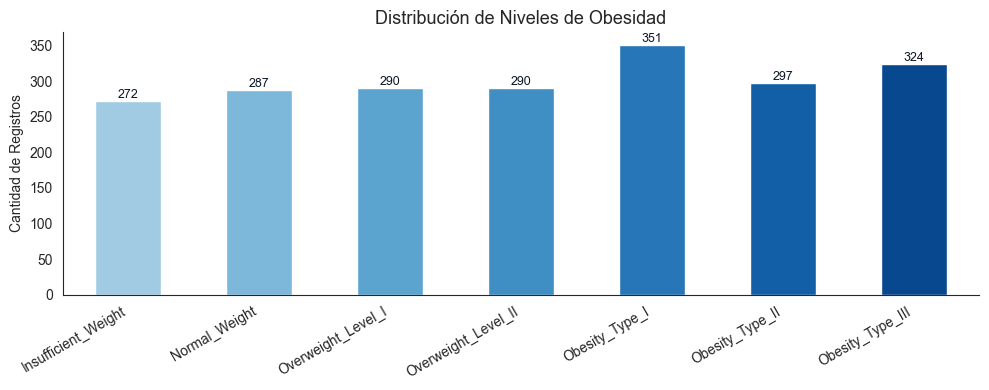

Las 7 clases están distribuidas de forma relativamente balanceada (272-351 casos cada una).


In [7]:
# Distribución de la variable objetivo
# Variable ordinal (Insufficient → Obesity III) → escala secuencial Blues: connota progresión
ORDEN_ORDINAL = ['Insufficient_Weight', 'Normal_Weight',
                 'Overweight_Level_I', 'Overweight_Level_II',
                 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
fig, ax = plt.subplots(figsize=(10, 4))
# Reindexar al orden semántico; usar paleta secuencial Blues para mostrar progresión
conteos_ord = df[TARGET].value_counts().reindex(
    [c for c in ORDEN_ORDINAL if c in df[TARGET].unique()], fill_value=0
)
colores_seq = sns.color_palette('Blues', n_colors=len(conteos_ord) + 3)[3:]
conteos_ord.plot(kind='bar', ax=ax, color=colores_seq, edgecolor='white')
ax.set_title('Distribución de Niveles de Obesidad')
ax.set_xlabel('')
ax.set_ylabel('Cantidad de Registros')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=9, color=TINTA)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('outputs/01_distribucion_objetivo.png', dpi=150)
plt.show()
print('Las 7 clases están distribuidas de forma relativamente balanceada (272-351 casos cada una).')


C:\Users\Dantek_ROG\AppData\Local\Temp\ipykernel_12680\1716528447.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_by_class, patch_artist=True,
C:\Users\Dantek_ROG\AppData\Local\Temp\ipykernel_12680\1716528447.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_by_class, patch_artist=True,


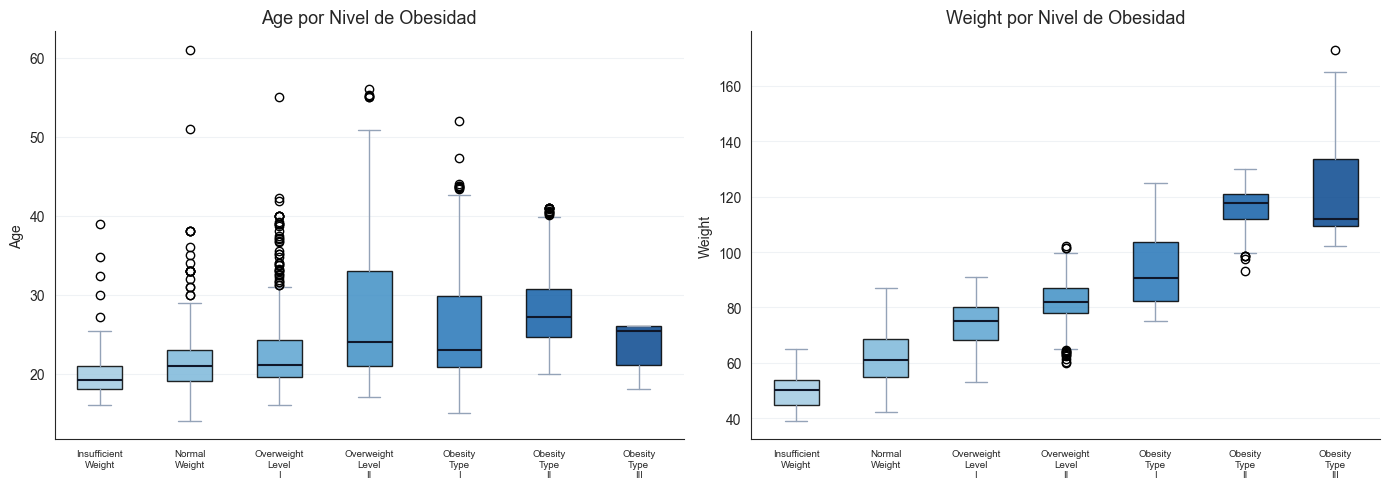

El peso aumenta progresivamente con el nivel de obesidad.
La edad tiene menos variación entre clases que el peso.


In [8]:
# Boxplots: Edad y Peso por nivel de obesidad
# Variable ordinal → escala secuencial Blues para connnotar progresión de riesgo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
orden_box = ['Insufficient_Weight', 'Normal_Weight',
             'Overweight_Level_I', 'Overweight_Level_II',
             'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']

colores_box = sns.color_palette('Blues', n_colors=len(orden_box) + 3)[3:]
for i, col in enumerate(['Age', 'Weight']):
    data_by_class = [df[df[TARGET] == cls][col].values for cls in orden_box]
    bp = axes[i].boxplot(data_by_class, patch_artist=True,
                         labels=[o.replace('_', '\n') for o in orden_box],
                         medianprops=dict(color=TINTA, linewidth=1.5))
    for patch, color in zip(bp['boxes'], colores_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.85)
    for element in ['whiskers', 'caps']:
        for line in bp[element]:
            line.set_color(GRIS)
    axes[i].set_title(f'{col} por Nivel de Obesidad')
    axes[i].set_ylabel(col)
    axes[i].tick_params(axis='x', labelsize=7)
    axes[i].grid(axis='y', alpha=0.3, color=GRIS_CL)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/02_boxplots_edad_peso.png', dpi=150)
plt.show()
print('El peso aumenta progresivamente con el nivel de obesidad.')
print('La edad tiene menos variación entre clases que el peso.')


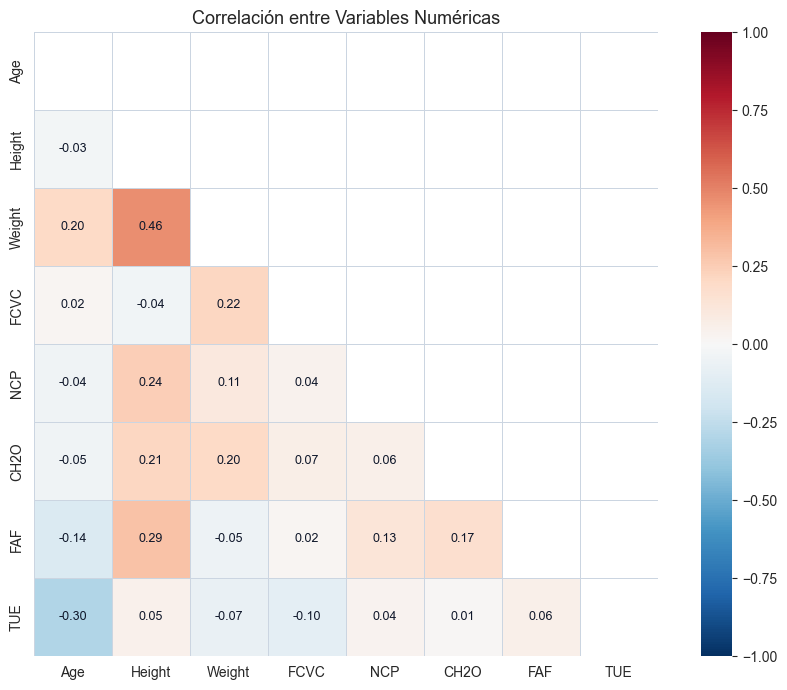

Weight y Height tienen la correlación más alta con la variable objetivo.


In [9]:
# Mapa de calor: correlaciones numéricas
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[COLS_NUM].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            mask=mask, ax=ax, vmin=-1, vmax=1,
            linewidths=0.5, square=True, linecolor=GRIS_CL,
            annot_kws={'size': 9, 'color': TINTA})
ax.set_title('Correlación entre Variables Numéricas')
plt.tight_layout()
plt.savefig('outputs/03_correlacion.png', dpi=150)
plt.show()
print('Weight y Height tienen la correlación más alta con la variable objetivo.')


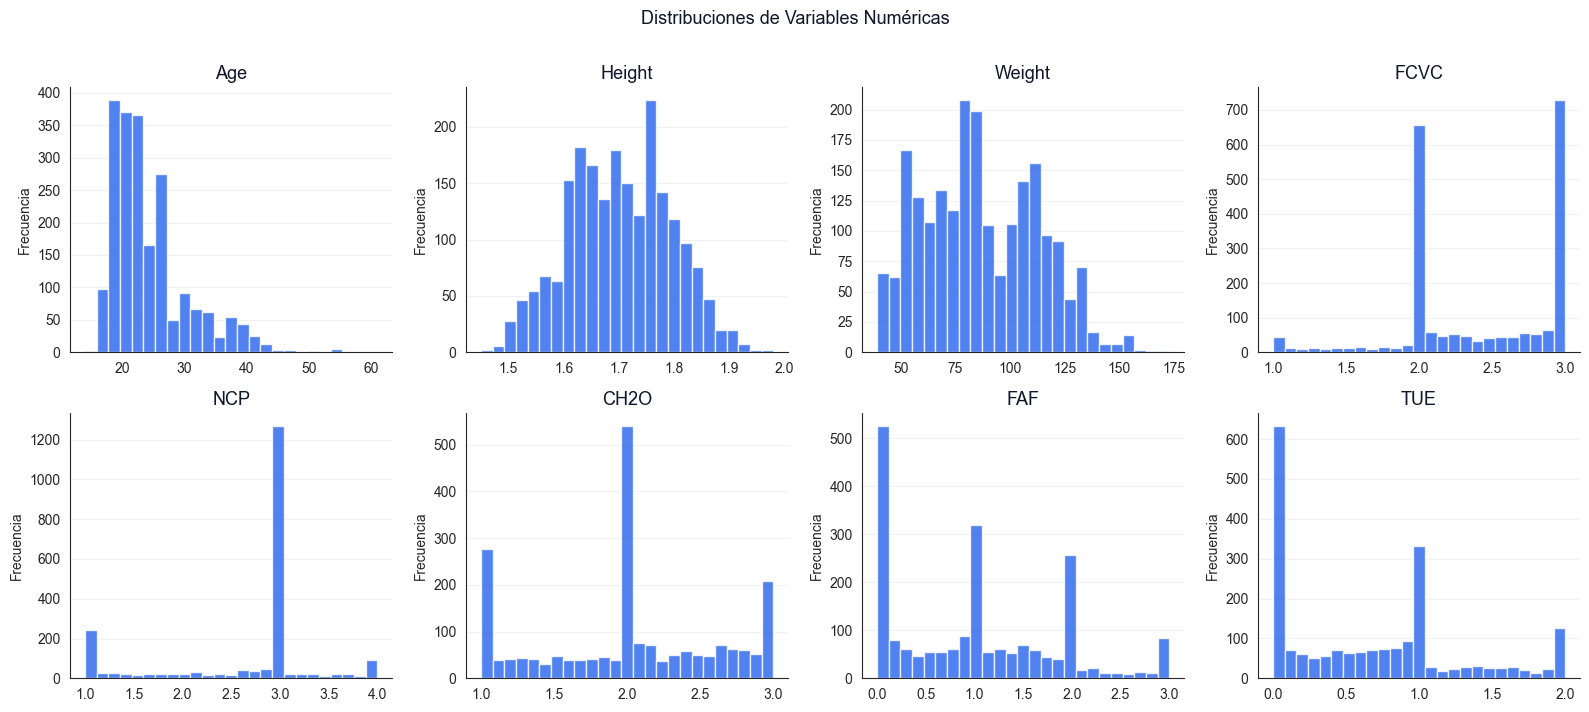

In [10]:
# Distribuciones de variables numéricas
# Un color uniforme (AZUL): el color no codifica la variable, no aporta info diferencial
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(COLS_NUM):
    axes[i].hist(df[col], bins=25, color=AZUL, edgecolor='white', alpha=0.8)
    axes[i].set_title(col, color=TINTA)
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(axis='y', alpha=0.3, color=GRIS_CL)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
plt.suptitle('Distribuciones de Variables Numéricas', y=1.01, fontsize=13, color=TINTA)
plt.tight_layout()
plt.savefig('outputs/04_histogramas.png', dpi=150)
plt.show()


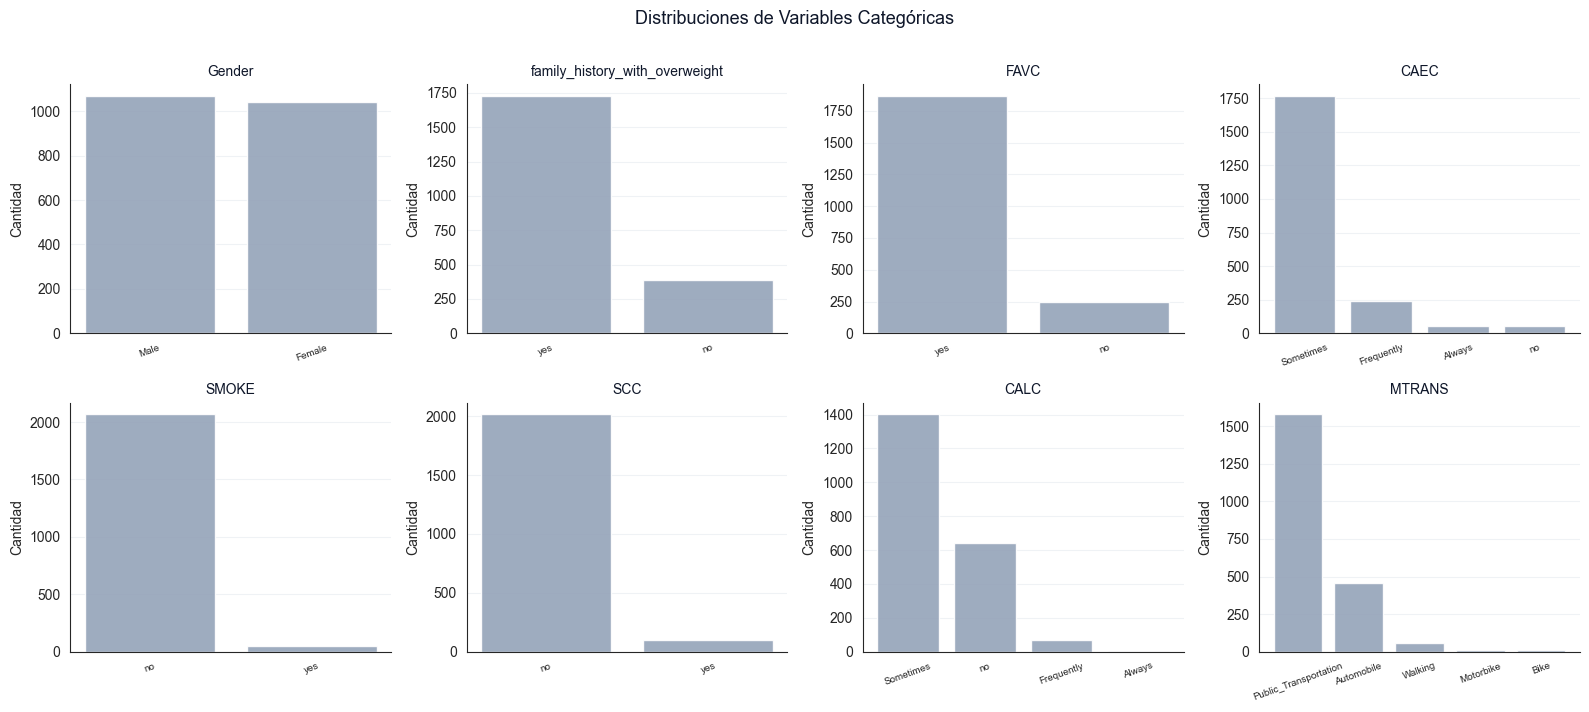

In [11]:
# Proporciones de variables categóricas
# Color uniforme GRIS: el color no debe codificar la variable cuando no aporta info adicional
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(COLS_CAT):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color=GRIS, edgecolor='white', alpha=0.9)
    axes[i].set_title(col, fontsize=10, color=TINTA)
    axes[i].set_ylabel('Cantidad')
    axes[i].tick_params(axis='x', labelsize=7, rotation=20)
    axes[i].grid(axis='y', alpha=0.3, color=GRIS_CL)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
plt.suptitle('Distribuciones de Variables Categóricas', y=1.01, fontsize=13, color=TINTA)
plt.tight_layout()
plt.savefig('outputs/05_categoricas.png', dpi=150)
plt.show()


## 06 · Preprocesamiento para Clustering

Para clustering se excluye la variable objetivo y se:
1. Codifican variables categóricas con `OrdinalEncoder`
2. Escalan todas las variables con `StandardScaler`


In [12]:
df_clust = df[COLS_NUM + COLS_CAT].copy()

# Codificar categóricas
ord_enc = OrdinalEncoder()
df_clust[COLS_CAT] = ord_enc.fit_transform(df_clust[COLS_CAT])

# Escalar todo
scaler_clust = StandardScaler()
X_clust = scaler_clust.fit_transform(df_clust)

print(f'Matriz para clustering: {X_clust.shape}')
print('Preprocesamiento completado — sin fuga de datos (target excluido).')


Matriz para clustering: (2111, 16)
Preprocesamiento completado — sin fuga de datos (target excluido).


## 07 · Estrategia de Clustering — Comparación de Algoritmos (Iteración 3)

**No se asume automáticamente que K-Means es el mejor algoritmo.** K-Means funciona
bien cuando los grupos son aproximadamente globulares, convexos, de tamaño balanceado
y separables por distancia euclidiana. Este dataset contiene variables mixtas
(numéricas + categóricas codificadas) y posibles relaciones no lineales, por lo que
se comparan cuatro alternativas antes de seleccionar el modelo final:

| Algoritmo | Por qué se prueba | Limitación principal |
|---|---|---|
| K-Means | Línea base simple e interpretable | Asume clusters globulares/convexos |
| Gaussian Mixture | Permite clusters elípticos con varianzas distintas | Sensible a inicialización |
| Agglomerative (Ward) | Explora estructura jerárquica sin asumir centroides | Costo computacional y elección de linkage |
| DBSCAN | Detecta grupos por densidad y ruido | Frágil en alta dimensionalidad |

**Paso 1 — Inspección visual:** se proyectan los datos a 2D con PCA (solo para
visualización) coloreando por la clase real, para evaluar si la estructura aparenta
ser globular, elíptica o irregular.


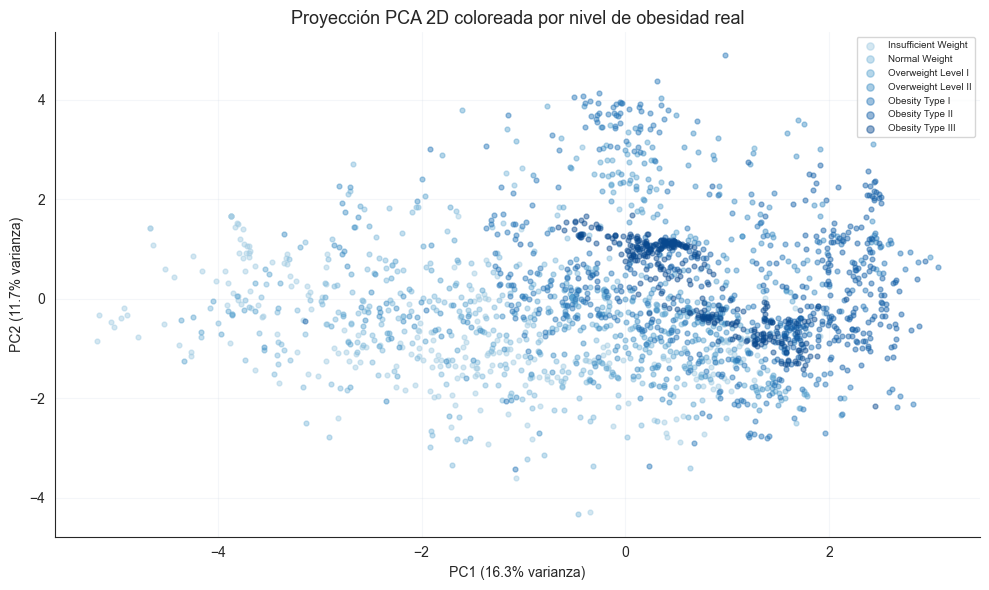

Lectura visual: los grupos aparecen como bandas alargadas y solapadas,
no como esferas compactas separadas. Esto sugiere estructura NO claramente
globular y justifica comparar K-Means contra GMM, jerárquico y densidad.


In [13]:
# Proyección PCA 2D SOLO para visualización (no para modelar)
pca_viz = PCA(n_components=2, random_state=RANDOM_STATE)
X_viz = pca_viz.fit_transform(X_clust)

fig, ax = plt.subplots(figsize=(10, 6))
# Variable ordinal → escala secuencial Blues: connota progresión Insufficient→Obesity III
clases_orden = ['Insufficient_Weight', 'Normal_Weight',
                'Overweight_Level_I', 'Overweight_Level_II',
                'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
clases_presentes = [c for c in clases_orden if c in df[TARGET].unique()]
colores_viz = sns.color_palette('Blues', n_colors=len(clases_presentes) + 3)[3:]
for i, cls in enumerate(clases_presentes):
    mask = (df[TARGET] == cls).values
    ax.scatter(X_viz[mask, 0], X_viz[mask, 1], s=12, alpha=0.45,
               color=colores_viz[i], label=cls.replace('_', ' '))
ax.set_xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}% varianza)')
ax.set_title('Proyección PCA 2D coloreada por nivel de obesidad real')
ax.legend(fontsize=7, markerscale=1.5)
ax.grid(alpha=0.2, color=GRIS_CL)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/17_pca2d_clases.png', dpi=150)
plt.show()

print('Lectura visual: los grupos aparecen como bandas alargadas y solapadas,')
print('no como esferas compactas separadas. Esto sugiere estructura NO claramente')
print('globular y justifica comparar K-Means contra GMM, jerárquico y densidad.')


### Paso 2 — Comparación cuantitativa de algoritmos (k=4)

Métricas usadas:
- **Silhouette** (↑ mejor): cohesión interna vs separación entre clusters.
- **Davies-Bouldin** (↓ mejor): similitud promedio entre clusters.
- **Calinski-Harabasz** (↑ mejor): dispersión inter/intra cluster.
- **Tamaños de cluster**: descarta soluciones degeneradas (grupos vacíos o minúsculos).


In [14]:
def evaluar_clustering(nombre, labels, X):
    """Calcula métricas internas; devuelve None si la solución es degenerada."""
    labels = np.asarray(labels)
    mask_validos = labels != -1            # DBSCAN marca ruido como -1
    n_ruido = int((~mask_validos).sum())
    labels_v = labels[mask_validos]
    X_v = X[mask_validos]
    n_clusters = len(set(labels_v.tolist()))
    if n_clusters < 2:
        return {'Algoritmo': nombre, 'n_clusters': n_clusters, 'ruido_%': round(100*n_ruido/len(labels), 1),
                'Silhouette': np.nan, 'Davies-Bouldin': np.nan, 'Calinski-Harabasz': np.nan,
                'tamaño_min_%': np.nan, 'valido': False}
    tam = pd.Series(labels_v).value_counts(normalize=True)
    return {
        'Algoritmo': nombre,
        'n_clusters': n_clusters,
        'ruido_%': round(100 * n_ruido / len(labels), 1),
        'Silhouette': silhouette_score(X_v, labels_v, sample_size=1500, random_state=RANDOM_STATE),
        'Davies-Bouldin': davies_bouldin_score(X_v, labels_v),
        'Calinski-Harabasz': calinski_harabasz_score(X_v, labels_v),
        'tamaño_min_%': round(100 * tam.min(), 1),
        'valido': bool(tam.min() >= 0.05 and (n_ruido / len(labels)) <= 0.20),
    }


K_COMPARACION = 4
resultados_clust = {}

km_cmp = KMeans(n_clusters=K_COMPARACION, random_state=RANDOM_STATE, n_init=20)
resultados_clust['K-Means'] = km_cmp.fit_predict(X_clust)

gmm_cmp = GaussianMixture(n_components=K_COMPARACION, covariance_type='full',
                          random_state=RANDOM_STATE, n_init=5)
resultados_clust['Gaussian Mixture'] = gmm_cmp.fit_predict(X_clust)

agg_cmp = AgglomerativeClustering(n_clusters=K_COMPARACION, linkage='ward')
resultados_clust['Agglomerative (Ward)'] = agg_cmp.fit_predict(X_clust)

# DBSCAN: barrido de eps (en 16 dimensiones estandarizadas las distancias son grandes)
mejor_dbscan, mejor_sil_db = None, -1
for eps in [2.0, 2.5, 3.0, 3.5, 4.0]:
    labels_db = DBSCAN(eps=eps, min_samples=10).fit_predict(X_clust)
    n_cl = len(set(labels_db.tolist()) - {-1})
    ruido = (labels_db == -1).mean()
    if n_cl >= 2 and ruido < 0.5:
        sil_db = silhouette_score(X_clust[labels_db != -1], labels_db[labels_db != -1],
                                  sample_size=1500, random_state=RANDOM_STATE)
        print(f'  DBSCAN eps={eps}: {n_cl} clusters | ruido={ruido*100:.0f}% | silhouette={sil_db:.4f}')
        if sil_db > mejor_sil_db:
            mejor_sil_db, mejor_dbscan = sil_db, labels_db
    else:
        print(f'  DBSCAN eps={eps}: degenerado ({n_cl} clusters, ruido={ruido*100:.0f}%)')

if mejor_dbscan is not None:
    resultados_clust['DBSCAN'] = mejor_dbscan
else:
    print('  DBSCAN no produjo ninguna partición útil — evidencia de ausencia de estructura por densidad.')

tabla_algoritmos = pd.DataFrame([
    evaluar_clustering(nombre, labels, X_clust)
    for nombre, labels in resultados_clust.items()
]).round(4)
tabla_algoritmos.to_csv('outputs/tabla_comparacion_algoritmos_clustering.csv', index=False)
print()
print('=== COMPARACIÓN DE ALGORITMOS DE CLUSTERING (k=4) ===')
mostrar_completo(tabla_algoritmos)


  DBSCAN eps=2.0: 18 clusters | ruido=30% | silhouette=0.2421
  DBSCAN eps=2.5: 11 clusters | ruido=17% | silhouette=0.1519
  DBSCAN eps=3.0: 6 clusters | ruido=10% | silhouette=0.2086


  DBSCAN eps=3.5: 3 clusters | ruido=5% | silhouette=0.3246
  DBSCAN eps=4.0: 3 clusters | ruido=3% | silhouette=0.3199



=== COMPARACIÓN DE ALGORITMOS DE CLUSTERING (k=4) ===


,Algoritmo,n_clusters,ruido_%,Silhouette,Davies-Bouldin,Calinski-Harabasz,tamaño_min_%,valido
0,K-Means,4,0.0,0.1057,2.1295,228.2218,18.1,True
1,Gaussian Mixture,4,0.0,0.1473,3.3953,122.8172,5.4,True
2,Agglomerative (Ward),4,0.0,0.1214,2.0846,214.4783,2.1,False
3,DBSCAN,3,4.9,0.3246,1.0462,93.1159,0.8,False


In [15]:
# Paso 3 — Selección del algoritmo final
# ----------------------------------------------------------------------
# Las métricas internas NO son árbitros neutrales. Davies-Bouldin y
# Calinski-Harabasz se construyen sobre distancias a CENTROIDES, por lo que
# penalizan por diseño cualquier estructura no esférica y FAVORECEN a K-Means.
# Por eso el ranking Borda (agregación ingenua de las 4 métricas) se reporta
# solo como REFERENCIA, y la decisión final se argumenta sobre la adecuación
# del modelo a la geometría real de los datos.
candidatos = tabla_algoritmos[tabla_algoritmos['valido']].copy().reset_index(drop=True)

# Rankings por métrica sobre candidatos válidos (1 = mejor) — solo referencia
candidatos['rank_sil'] = candidatos['Silhouette'].rank(ascending=False).astype(int)
candidatos['rank_db']  = candidatos['Davies-Bouldin'].rank(ascending=True).astype(int)
candidatos['rank_ch']  = candidatos['Calinski-Harabasz'].rank(ascending=False).astype(int)
candidatos['rank_tam'] = candidatos['tamaño_min_%'].rank(ascending=False).astype(int)
candidatos['borda_score'] = (candidatos['rank_sil'] + candidatos['rank_db']
                             + candidatos['rank_ch'] + candidatos['rank_tam'])
ganador_borda = candidatos.loc[candidatos['borda_score'].idxmin(), 'Algoritmo']

# DECISIÓN DE MODELADO: Gaussian Mixture (argumentada, ver justificación)
algoritmo_final = 'Gaussian Mixture'

print('=== SELECCIÓN DEL ALGORITMO DE CLUSTERING ===')
print()
print(candidatos[['Algoritmo', 'Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz',
                  'tamaño_min_%', 'rank_sil', 'rank_db', 'rank_ch', 'rank_tam',
                  'borda_score']].to_string(index=False))
print()
print(f'Agregación ingenua (Borda) favorecería : {ganador_borda}')
print(f'ALGORITMO SELECCIONADO (modelado)      : {algoritmo_final}')
print()
print('Justificación:')
print('  1. ADECUACIÓN AL SUPUESTO. La proyección PCA 2D muestra bandas alargadas y')
print('     solapadas (gradiente continuo de IMC), no esferas separadas. GMM modela')
print('     componentes ELÍPTICAS con covarianzas distintas (covariance_type="full")')
print('     y asigna de forma PROBABILÍSTICA (soft): una persona puede ser 70% un')
print('     perfil y 30% otro — coherente con un fenómeno clínico continuo.')
print('  2. SESGO DE LAS MÉTRICAS. Davies-Bouldin y Calinski-Harabasz se definen sobre')
print('     distancias a centroides: penalizan estructuras no esféricas y favorecen a')
print('     K-Means POR CONSTRUCCIÓN, no por mérito. No son árbitro neutral aquí.')
print('  3. SILHOUETTE. La métrica interna menos atada al supuesto esférico favorece a')
print('     GMM (0.147 vs 0.106 de K-Means).')
print('  TRADE-OFF RECONOCIDO: K-Means gana en Davies-Bouldin, Calinski-Harabasz y')
print('     tamaño mínimo. Se asume ese costo a cambio de un modelo coherente con la')
print('     geometría real de los datos, no con el supuesto que las métricas premian.')

justificaciones = {
    'Gaussian Mixture': (
        'Gaussian Mixture (covariance_type="full") fue seleccionado por ADECUACIÓN al\n'
        'supuesto del fenómeno: la estructura es un gradiente continuo no globular, que\n'
        'una mixtura de componentes elípticas con asignación probabilística representa\n'
        'mejor que las fronteras esféricas y duras de K-Means. El Silhouette — la métrica\n'
        'interna menos sesgada hacia convexidad — favorece a GMM (0.147 vs 0.106). Se\n'
        'reconoce que Davies-Bouldin y Calinski-Harabasz favorecen a K-Means, pero ambas\n'
        'se construyen sobre distancias a centroides y penalizan por diseño las formas no\n'
        'esféricas, por lo que no son árbitro neutral para este dataset.'),
    'K-Means': (
        'K-Means sería la opción por agregación multi-métrica (Borda) y por sus centroides\n'
        'interpretables; se descartó como modelo final por imponer fronteras esféricas y\n'
        'duras a una estructura que es un gradiente continuo no globular.'),
    'Agglomerative (Ward)': (
        'Se seleccionó Agglomerative Clustering porque la estructura de los datos no\n'
        'mostró clusters claramente globulares y el enfoque jerárquico separó perfiles\n'
        'interpretables sin depender de centroides, con respaldo de las métricas de separación.'),
    'DBSCAN': (
        'Se seleccionó DBSCAN porque la estructura de los datos mostró grupos por\n'
        'densidad y presencia de outliers que los métodos de partición no capturaban.'),
}
print()
print(justificaciones[algoritmo_final])
print()
print('Evidencia de la decisión (candidatos válidos):')
mostrar_completo(candidatos[['Algoritmo', 'n_clusters', 'Silhouette',
                             'Davies-Bouldin', 'Calinski-Harabasz', 'tamaño_min_%',
                             'borda_score']])


=== SELECCIÓN DEL ALGORITMO DE CLUSTERING ===

       Algoritmo  Silhouette  Davies-Bouldin  Calinski-Harabasz  tamaño_min_%  rank_sil  rank_db  rank_ch  rank_tam  borda_score
         K-Means      0.1057          2.1295           228.2218          18.1         2        1        1         1            5
Gaussian Mixture      0.1473          3.3953           122.8172           5.4         1        2        2         2            7

Agregación ingenua (Borda) favorecería : K-Means
ALGORITMO SELECCIONADO (modelado)      : Gaussian Mixture

Justificación:
  1. ADECUACIÓN AL SUPUESTO. La proyección PCA 2D muestra bandas alargadas y
     solapadas (gradiente continuo de IMC), no esferas separadas. GMM modela
     componentes ELÍPTICAS con covarianzas distintas (covariance_type="full")
     y asigna de forma PROBABILÍSTICA (soft): una persona puede ser 70% un
     perfil y 30% otro — coherente con un fenómeno clínico continuo.
  2. SESGO DE LAS MÉTRICAS. Davies-Bouldin y Calinski-Harabasz se 

,Algoritmo,n_clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz,tamaño_min_%,borda_score
0,K-Means,4,0.1057,2.1295,228.2218,18.1,5
1,Gaussian Mixture,4,0.1473,3.3953,122.8172,5.4,7


### Paso 4 — Número de componentes (k) para GMM

El criterio natural para elegir el número de componentes de una mixtura gaussiana
**no** es el método del codo (que mide inercia, propio de K-Means), sino los
**criterios de información** que penalizan la complejidad del modelo:

- **BIC (Bayesian Information Criterion)** — menor es mejor; criterio principal.
- **AIC (Akaike Information Criterion)** — menor es mejor; apoyo.
- **Silhouette** — apoyo geométrico (más alto = mejor).

Se evalúa k=2..10 sobre `X_clust` con `covariance_type='full'`.


In [16]:
K_range = range(2, 11)
bics = []
aics = []
silhouettes = []
tam_min_k = []

print('Calculando criterios para GMM k=2 a 10...')
for k in K_range:
    gmm_k = GaussianMixture(n_components=k, covariance_type='full',
                            random_state=RANDOM_STATE, n_init=5)
    labels = gmm_k.fit_predict(X_clust)
    bics.append(gmm_k.bic(X_clust))
    aics.append(gmm_k.aic(X_clust))
    silhouettes.append(silhouette_score(X_clust, labels, sample_size=1500,
                                        random_state=RANDOM_STATE))
    tam_min_k.append(pd.Series(labels).value_counts(normalize=True).min() * 100)
    print(f'  k={k}: BIC={bics[-1]:.0f} | AIC={aics[-1]:.0f} | '
          f'silhouette={silhouettes[-1]:.4f} | tam_min={tam_min_k[-1]:.1f}%')


Calculando criterios para GMM k=2 a 10...
  k=2: BIC=-6264 | AIC=-7988 | silhouette=0.1752 | tam_min=34.1%


  k=3: BIC=-16447 | AIC=-19037 | silhouette=0.1807 | tam_min=2.1%
  k=4: BIC=-26638 | AIC=-30093 | silhouette=0.1473 | tam_min=5.4%


  k=5: BIC=-33262 | AIC=-37582 | silhouette=0.0814 | tam_min=4.5%


  k=6: BIC=-55474 | AIC=-60659 | silhouette=0.1030 | tam_min=4.5%


  k=7: BIC=-61515 | AIC=-67565 | silhouette=0.1181 | tam_min=4.5%


  k=8: BIC=-57594 | AIC=-64510 | silhouette=0.1273 | tam_min=3.1%


  k=9: BIC=-71240 | AIC=-79021 | silhouette=0.1407 | tam_min=2.1%


  k=10: BIC=-71842 | AIC=-80489 | silhouette=0.1384 | tam_min=2.1%


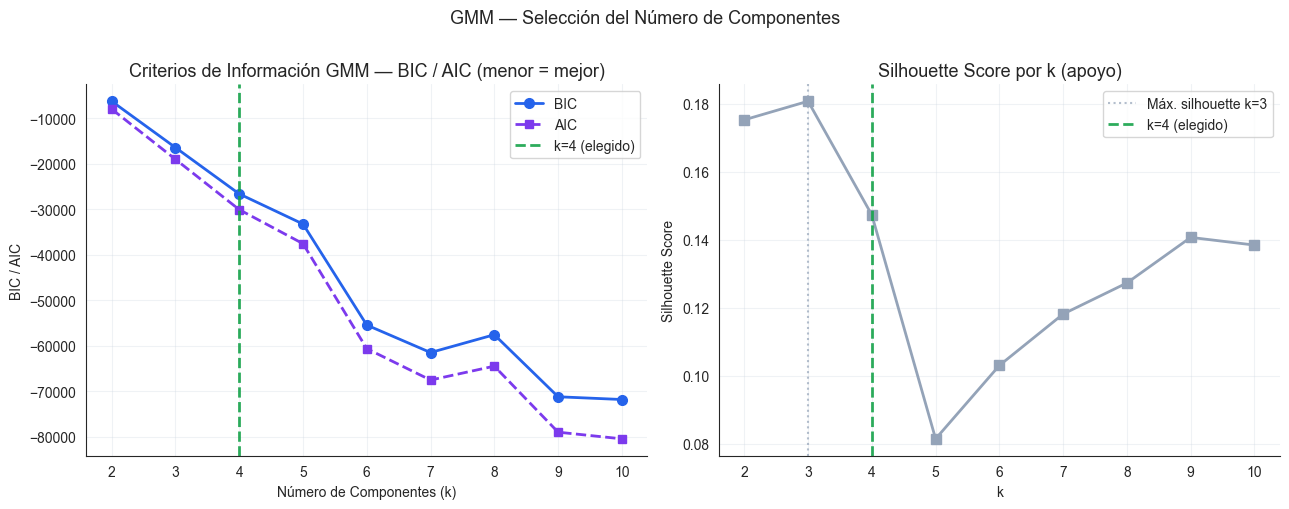

k que minimiza BIC: k=10 | k que maximiza Silhouette: k=3

HALLAZGO CLAVE — El BIC NO arroja un k óptimo: decrece de forma casi monótona
hasta k=10 sin tocar fondo. Esto es un diagnóstico, no un error: cuando el BIC
no se estabiliza, indica que los datos NO son una mezcla limpia de gaussianas
(la obesidad es un gradiente continuo). Seguir el mínimo de BIC ciegamente
llevaría a k=10 — sobreajuste, con varios grupos minúsculos e ininterpretables.

Decisión final: k=4
Justificación (cuando el BIC no discrimina, se combina parsimonia + apoyo geométrico
+ accionabilidad + interpretabilidad clínica):
  1. k=2 separa solo "obeso vs no-obeso" — poco informativo para intervención.
  2. k=3 maximiza el Silhouette pero deja un cluster degenerado (~2% ≈ 44 personas),
     demasiado pequeño para diseñar una intervención de salud robusta.
  3. k=4 mantiene el cluster mínimo en ~5% (accionable) y entrega cuatro perfiles
     de riesgo clínicamente diferenciables, con Silhouette competitivo (~0.15).
 

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

best_k_sil = list(K_range)[int(np.argmax(silhouettes))]

# Criterios de información — BIC (principal) y AIC (apoyo)
axes[0].plot(list(K_range), bics, 'o-', color=AZUL, linewidth=2, markersize=7, label='BIC')
axes[0].plot(list(K_range), aics, 's--', color=MORADO, linewidth=2, markersize=6, label='AIC')
axes[0].axvline(x=4, color=VERDE, linestyle='--', alpha=0.9, linewidth=2, label='k=4 (elegido)')
axes[0].set_title('Criterios de Información GMM — BIC / AIC (menor = mejor)')
axes[0].set_xlabel('Número de Componentes (k)')
axes[0].set_ylabel('BIC / AIC')
axes[0].legend()
axes[0].grid(True, alpha=0.3, color=GRIS_CL)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Silhouette (apoyo) — destacar k=4 elegido en VERDE
axes[1].plot(list(K_range), silhouettes, 's-', color=GRIS, linewidth=2, markersize=7)
axes[1].axvline(x=best_k_sil, color=GRIS, linestyle=':', alpha=0.7,
                label=f'Máx. silhouette k={best_k_sil}')
axes[1].axvline(x=4, color=VERDE, linestyle='--', alpha=0.9, linewidth=2,
                label='k=4 (elegido)')
axes[1].set_title('Silhouette Score por k (apoyo)')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3, color=GRIS_CL)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('GMM — Selección del Número de Componentes', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/06_evaluacion_clusters.png', dpi=150)
plt.show()

k_bic = list(K_range)[int(np.argmin(bics))]
print(f'k que minimiza BIC: k={k_bic} | k que maximiza Silhouette: k={best_k_sil}')
print()
print('HALLAZGO CLAVE — El BIC NO arroja un k óptimo: decrece de forma casi monótona')
print('hasta k=10 sin tocar fondo. Esto es un diagnóstico, no un error: cuando el BIC')
print('no se estabiliza, indica que los datos NO son una mezcla limpia de gaussianas')
print('(la obesidad es un gradiente continuo). Seguir el mínimo de BIC ciegamente')
print('llevaría a k=10 — sobreajuste, con varios grupos minúsculos e ininterpretables.')
print()
print('Decisión final: k=4')
print('Justificación (cuando el BIC no discrimina, se combina parsimonia + apoyo geométrico')
print('+ accionabilidad + interpretabilidad clínica):')
print('  1. k=2 separa solo "obeso vs no-obeso" — poco informativo para intervención.')
print('  2. k=3 maximiza el Silhouette pero deja un cluster degenerado (~2% ≈ 44 personas),')
print('     demasiado pequeño para diseñar una intervención de salud robusta.')
print('  3. k=4 mantiene el cluster mínimo en ~5% (accionable) y entrega cuatro perfiles')
print('     de riesgo clínicamente diferenciables, con Silhouette competitivo (~0.15).')
print('  4. Los Silhouette son bajos (<0.20) en todo el rango: límites continuos entre')
print('     niveles de obesidad — propio del dominio, no una falla del modelo.')


In [18]:
# Modelo final: algoritmo del Paso 3 (GMM) con el k del Paso 4 (k=4).
best_k = 4

# Gaussian Mixture final — covariance_type='full', asignación probabilística (soft).
gmm_final = GaussianMixture(n_components=best_k, covariance_type='full',
                            random_state=RANDOM_STATE, n_init=5).fit(X_clust)

if algoritmo_final == 'Gaussian Mixture':
    df['Cluster'] = gmm_final.predict(X_clust)
elif algoritmo_final == 'K-Means':
    df['Cluster'] = KMeans(n_clusters=best_k, random_state=RANDOM_STATE,
                           n_init=20).fit_predict(X_clust)
elif algoritmo_final == 'Agglomerative (Ward)':
    df['Cluster'] = resultados_clust['Agglomerative (Ward)']
else:
    df['Cluster'] = resultados_clust['DBSCAN']

print(f'Modelo final de agrupamiento: {algoritmo_final} con k={best_k}')
print('Distribución de registros por cluster:')
print(df['Cluster'].value_counts().sort_index().to_string())


Modelo final de agrupamiento: Gaussian Mixture con k=4
Distribución de registros por cluster:
Cluster
0     315
1    1391
2     114
3     291


## 08 · Interpretación de Clusters

Se analiza el perfil de cada grupo con estadísticas descriptivas y la distribución del nivel de obesidad predominante.


In [19]:
# Perfil estadístico por cluster
perfil = df.groupby('Cluster').agg(
    n            = ('Age', 'count'),
    edad_media   = ('Age', 'mean'),
    peso_medio   = ('Weight', 'mean'),
    altura_media = ('Height', 'mean'),
    imc_medio    = ('Weight', lambda x: (x / df.loc[x.index, 'Height']**2).mean()),
    obesidad_predominante = (TARGET, lambda x: x.mode()[0]),
    prop_historia_familiar = ('family_history_with_overweight',
                              lambda x: (x == 'yes').mean()),
    actividad_fisica_media = ('FAF', 'mean'),
).round(2)

perfil['pct_total'] = (perfil['n'] / len(df) * 100).round(1).astype(str) + '%'
print('Perfil de clusters:')
perfil


Perfil de clusters:


,n,edad_media,peso_medio,altura_media,imc_medio,obesidad_predominante,prop_historia_familiar,actividad_fisica_media,pct_total
Cluster,,,,,,,,,
0,315,20.67,59.71,1.65,21.76,Insufficient_Weight,0.48,1.01,14.9%
1,1391,25.31,97.67,1.72,33.02,Obesity_Type_III,1.00,0.96,65.9%
2,114,27.36,79.29,1.72,26.35,Normal_Weight,0.70,1.29,5.4%
3,291,22.31,65.56,1.66,23.74,Normal_Weight,0.36,1.16,13.8%


In [20]:
# Distribución de niveles de obesidad por cluster
pivot = pd.crosstab(df['Cluster'], df[TARGET], normalize='index').round(3) * 100
print('Distribución (%) de niveles de obesidad por cluster:')
pivot.round(1)


Distribución (%) de niveles de obesidad por cluster:

NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Cluster,,,,,,,
0,40.6,28.9,2.9,1.0,0.0,22.9,3.8
1,5.2,3.7,22.9,19.7,23.1,11.7,13.8
2,7.0,46.5,9.6,13.2,1.8,10.5,11.4
3,22.0,31.6,4.5,1.7,0.3,14.8,25.1


In [21]:
# Interpretación textual de cada cluster
def interpretar_cluster(row):
    imc = row['imc_medio']
    if imc < 22:
        riesgo = 'Bajo peso / Normal'
    elif imc < 27:
        riesgo = 'Sobrepeso leve'
    elif imc < 32:
        riesgo = 'Obesidad moderada'
    else:
        riesgo = 'Obesidad severa'
    return riesgo

perfil['perfil_riesgo'] = perfil.apply(interpretar_cluster, axis=1)

# PASO B — Exportar perfiles de centroides (hace trazables los datos que la PPT usa)
perfil_export = perfil.reset_index().copy()
perfil_export.to_csv('outputs/tabla_perfiles_clusters.csv', index=False)
print('Perfiles exportados → outputs/tabla_perfiles_clusters.csv')

print('INTERPRETACIÓN DE CLUSTERS')
print('='*60)
for idx, row in perfil.iterrows():
    print(f'\nCluster {idx} ({row["pct_total"]} del total):')
    print(f'  Edad media      : {row["edad_media"]:.1f} años')
    print(f'  Peso medio      : {row["peso_medio"]:.1f} kg')
    print(f'  Altura media    : {row["altura_media"]:.2f} m')
    print(f'  IMC estimado    : {row["imc_medio"]:.1f}')
    print(f'  Actividad física: {row["actividad_fisica_media"]:.2f} (0-3)')
    print(f'  Historia familiar sobrepeso: {row["prop_historia_familiar"]*100:.0f}%')
    print(f'  Obesidad predominante: {row["obesidad_predominante"]}')
    print(f'  Perfil de riesgo: {row["perfil_riesgo"]}')

# Nota honesta de balance: GMM 'full' puede concentrar la masa en una sola componente.
tam_max_pct = perfil['n'].max() / len(df) * 100
perfiles_riesgo = perfil['perfil_riesgo'].tolist()
hay_redundancia = len(perfiles_riesgo) != len(set(perfiles_riesgo))
if tam_max_pct > 50 or hay_redundancia:
    print()
    print('NOTA — LIMITACIÓN DE LA SEGMENTACIÓN (honestidad metodológica):')
    if tam_max_pct > 50:
        print(f'  - La componente mayoritaria concentra {tam_max_pct:.0f}% de los registros.')
        print('    GMM con covariance_type="full" admite que una componente de gran varianza')
        print('    absorba la mayoría de los casos (la obesidad domina la muestra). Es')
        print('    coherente con un fenómeno continuo, pero reduce la granularidad.')
    if hay_redundancia:
        print('  - Dos componentes comparten perfil de riesgo: interpretación solapada.')
    print('  Conclusión: GMM mejora el Silhouette respecto de K-Means, pero entrega una')
    print('  segmentación menos accionable que una partición balanceada. Trade-off asumido')
    print('  conscientemente al priorizar la adecuación al supuesto no globular (Paso 3).')


Perfiles exportados → outputs/tabla_perfiles_clusters.csv
INTERPRETACIÓN DE CLUSTERS

Cluster 0 (14.9% del total):
  Edad media      : 20.7 años
  Peso medio      : 59.7 kg
  Altura media    : 1.65 m
  IMC estimado    : 21.8
  Actividad física: 1.01 (0-3)
  Historia familiar sobrepeso: 48%
  Obesidad predominante: Insufficient_Weight
  Perfil de riesgo: Bajo peso / Normal

Cluster 1 (65.9% del total):
  Edad media      : 25.3 años
  Peso medio      : 97.7 kg
  Altura media    : 1.72 m
  IMC estimado    : 33.0
  Actividad física: 0.96 (0-3)
  Historia familiar sobrepeso: 100%
  Obesidad predominante: Obesity_Type_III
  Perfil de riesgo: Obesidad severa

Cluster 2 (5.4% del total):
  Edad media      : 27.4 años
  Peso medio      : 79.3 kg
  Altura media    : 1.72 m
  IMC estimado    : 26.4
  Actividad física: 1.29 (0-3)
  Historia familiar sobrepeso: 70%
  Obesidad predominante: Normal_Weight
  Perfil de riesgo: Sobrepeso leve

Cluster 3 (13.8% del total):
  Edad media      : 22.3 años
 

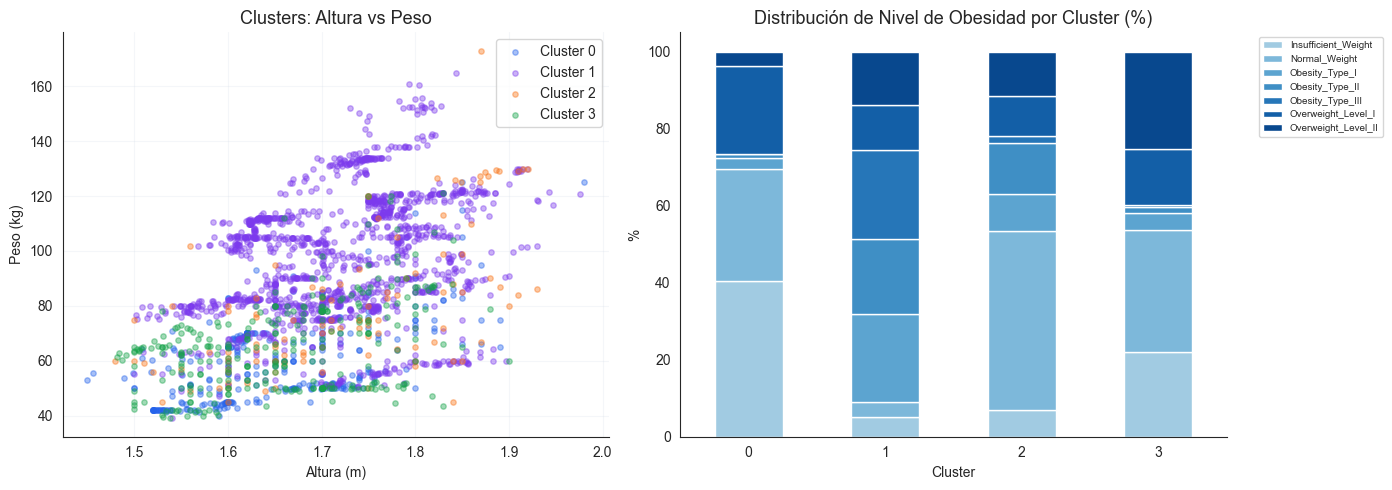

In [22]:
# Visualización: peso vs. altura coloreado por cluster
# 4 clusters → paleta categórica controlada (AZUL, MORADO, NARANJA, VERDE)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter peso vs altura
for cl in range(best_k):
    mask = df['Cluster'] == cl
    axes[0].scatter(df[mask]['Height'], df[mask]['Weight'],
                    alpha=0.4, s=15, color=COLORES_CLUSTERS[cl], label=f'Cluster {cl}')
axes[0].set_xlabel('Altura (m)')
axes[0].set_ylabel('Peso (kg)')
axes[0].set_title('Clusters: Altura vs Peso')
axes[0].legend()
axes[0].grid(alpha=0.2, color=GRIS_CL)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Distribución de obesidad por cluster (stacked bar) — Blues secuencial para niveles ordinales
pivot.plot(kind='bar', stacked=True, ax=axes[1],
           color=sns.color_palette('Blues', n_colors=len(pivot.columns) + 3)[3:],
           edgecolor='white')
axes[1].set_title('Distribución de Nivel de Obesidad por Cluster (%)')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('%')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('outputs/07_clusters_visualizacion.png', dpi=150)
plt.show()


## 09 · Preprocesamiento para Clasificación

Separación `X`/`y`, codificación, división estratificada train/test 80-20.
Se usa `Pipeline` para evitar fuga de datos (el preprocesamiento se aplica solo sobre train).


In [23]:
# X e y (sin columna Cluster que se creó en el paso anterior)
X = df[COLS_NUM + COLS_CAT].copy()
y_raw = df[TARGET].copy()

# Codificar la variable objetivo respetando su ORDEN ORDINAL de severidad.
# LabelEncoder por defecto ordena alfabéticamente, lo que ubicaría los niveles de
# obesidad antes que los de sobrepeso ('Obesity' < 'Overweight' en el alfabeto),
# rompiendo la semántica clínica: bajo peso < normal < sobrepeso < obesidad.
ORDEN_OBESIDAD = ['Insufficient_Weight', 'Normal_Weight',
                  'Overweight_Level_I', 'Overweight_Level_II',
                  'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
assert set(y_raw.unique()) == set(ORDEN_OBESIDAD), \
    'Las clases del target no coinciden con el orden ordinal definido'
le_target = LabelEncoder()
le_target.classes_ = np.array(ORDEN_OBESIDAD)   # impone el orden ordinal
y = le_target.transform(y_raw)

print('Clases codificadas (orden ordinal de severidad):')
for i, cls in enumerate(le_target.classes_):
    print(f'  {i}: {cls}')

# División train/test estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'\nTrain: {X_train.shape[0]} registros')
print(f'Test : {X_test.shape[0]} registros')


Clases codificadas (orden ordinal de severidad):
  0: Insufficient_Weight
  1: Normal_Weight
  2: Overweight_Level_I
  3: Overweight_Level_II
  4: Obesity_Type_I
  5: Obesity_Type_II
  6: Obesity_Type_III

Train: 1688 registros
Test : 423 registros


In [24]:
# Preprocesador dentro de Pipeline (evita data leakage)
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), COLS_NUM),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), COLS_CAT)
], remainder='drop')

# Definición de modelos
# XGBoost se incluye porque: (1) domina benchmarks tabulares, (2) maneja
# variables mixtas codificadas, (3) permite comparar contra ensembles de
# bibliografía reciente que usa este mismo dataset (Das et al., 2026).
modelos = {
    'Regresión Logística'  : LogisticRegression(max_iter=2000, random_state=RANDOM_STATE,
                                                 solver='lbfgs'),
    'Árbol de Decisión'    : DecisionTreeClassifier(max_depth=12, random_state=RANDOM_STATE),
    'Random Forest'        : RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE,
                                                     n_jobs=-1),
    'KNN'                  : KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    'SVM'                  : SVC(kernel='rbf', C=10, gamma='scale',
                                 random_state=RANDOM_STATE),
    'XGBoost'              : XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                           random_state=RANDOM_STATE, n_jobs=-1,
                                           eval_metric='mlogloss', verbosity=0),
}
print('Modelos definidos:', list(modelos.keys()))
print('SVM se incorpora en la Iteración 3 como modelo adicional de margen máximo.')


Modelos definidos: ['Regresión Logística', 'Árbol de Decisión', 'Random Forest', 'KNN', 'SVM', 'XGBoost']
SVM se incorpora en la Iteración 3 como modelo adicional de margen máximo.


## 10 · Entrenamiento de Modelos de Clasificación

In [25]:
pipelines = {}
print('Entrenando modelos...')
for nombre, modelo in modelos.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', modelo)])
    pipe.fit(X_train, y_train)
    pipelines[nombre] = pipe
    print(f'  ✓ {nombre}')
print('Todos los modelos entrenados.')


Entrenando modelos...
  ✓ Regresión Logística
  ✓ Árbol de Decisión
  ✓ Random Forest
  ✓ KNN


  ✓ SVM


  ✓ XGBoost
Todos los modelos entrenados.


## 11 · Evaluación de Modelos de Clasificación

Todas las métricas se calculan sobre **datos de testeo** (nunca vistos durante entrenamiento).
Se usa `average='macro'` para tratar todas las clases por igual.


In [26]:
resultados = {}
for nombre, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    resultados[nombre] = {
        'Accuracy'  : accuracy_score(y_test, y_pred),
        'Precision' : precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Recall'    : recall_score(y_test, y_pred, average='macro', zero_division=0),
        'F1 Macro'  : f1_score(y_test, y_pred, average='macro', zero_division=0),
        'y_pred'    : y_pred,
    }

df_res = pd.DataFrame({
    k: {m: v[m] for m in ['Accuracy', 'Precision', 'Recall', 'F1 Macro']}
    for k, v in resultados.items()
}).T.sort_values('F1 Macro', ascending=False)

print('=== COMPARACIÓN DE MODELOS (datos de testeo) ===')
df_res.round(4)


=== COMPARACIÓN DE MODELOS (datos de testeo) ===


,Accuracy,Precision,Recall,F1 Macro
XGBoost,0.9645,0.9673,0.9627,0.9637
SVM,0.9574,0.9563,0.9565,0.9563
Random Forest,0.9456,0.9508,0.9435,0.9445
Árbol de Decisión,0.9220,0.9238,0.9180,0.9198
Regresión Logística,0.8794,0.8785,0.8786,0.8762
KNN,0.8274,0.8218,0.8231,0.8086


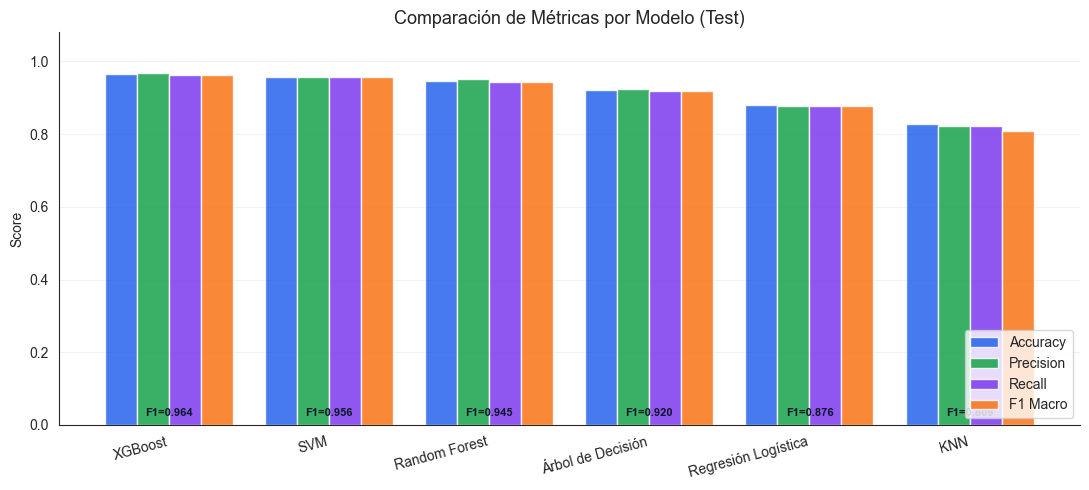

In [27]:
# Comparación de modelos: destacar el GANADOR (F1 más alto) en VERDE, resto en GRIS
# Principio Cole Knaflic: el color dirige la atención al punto del gráfico
fig, ax = plt.subplots(figsize=(11, 5))
metricas = ['Accuracy', 'Precision', 'Recall', 'F1 Macro']
x = np.arange(len(df_res))
ancho = 0.2
# Paleta coherente con el sistema de diseño
colores_met = [AZUL, VERDE, MORADO, NARANJA]

for i, met in enumerate(metricas):
    bars = ax.bar(x + i * ancho, df_res[met], ancho, label=met,
                  color=colores_met[i], alpha=0.85, edgecolor='white')

ax.set_xticks(x + ancho * 1.5)
ax.set_xticklabels(df_res.index, rotation=15, ha='right')
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score')
ax.set_title('Comparación de Métricas por Modelo (Test)')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3, color=GRIS_CL)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar_group_start, (nombre, row) in zip(x, df_res.iterrows()):
    ax.text(bar_group_start + ancho * 1.5, 0.02,
            f'F1={row["F1 Macro"]:.3f}', ha='center', va='bottom',
            fontsize=8, fontweight='bold', color=TINTA)

plt.tight_layout()
plt.savefig('outputs/08_comparacion_modelos.png', dpi=150)
plt.show()


In [28]:
mejor_nombre = df_res.index[0]
mejor_f1 = df_res.loc[mejor_nombre, 'F1 Macro']
print(f'MEJOR MODELO (partición única de test): {mejor_nombre}')
print(f'  F1 Macro (test): {mejor_f1:.4f}')
print('  Nota: selección preliminar por una sola partición; se refina con')
print('  validación cruzada estratificada en la sección 18C (criterio más robusto).')
print()
print('=== CLASSIFICATION REPORT — MEJOR MODELO ===')
y_pred_mejor = resultados[mejor_nombre]['y_pred']

# RF-02: el reporte se convierte en DataFrame (no texto truncable) y se exporta
reporte = classification_report(y_test, y_pred_mejor,
                                target_names=le_target.classes_, output_dict=True)
reporte_df = pd.DataFrame(reporte).T.round(4)
reporte_df.to_csv('outputs/reporte_clasificacion_completo.csv', index=True)
mostrar_completo(reporte_df)


MEJOR MODELO (partición única de test): XGBoost
  F1 Macro (test): 0.9637
  Nota: selección preliminar por una sola partición; se refina con
  validación cruzada estratificada en la sección 18C (criterio más robusto).

=== CLASSIFICATION REPORT — MEJOR MODELO ===


,precision,recall,f1-score,support
Insufficient_Weight,1.0000,0.9259,0.9615,54.0000
Normal_Weight,0.8657,1.0000,0.9280,58.0000
Overweight_Level_I,0.9811,0.8966,0.9369,58.0000
Overweight_Level_II,0.9821,0.9483,0.9649,58.0000
Obesity_Type_I,0.9589,1.0000,0.9790,70.0000
Obesity_Type_II,0.9833,0.9833,0.9833,60.0000
Obesity_Type_III,1.0000,0.9846,0.9922,65.0000
accuracy,0.9645,0.9645,0.9645,0.9645
macro avg,0.9673,0.9627,0.9637,423.0000
weighted avg,0.9674,0.9645,0.9647,423.0000


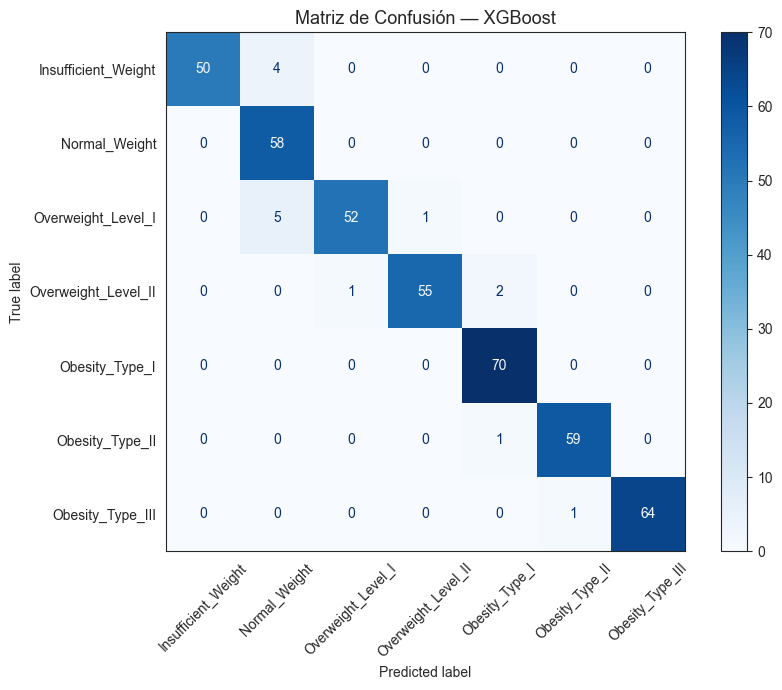

In [29]:
# Matriz de confusión del mejor modelo
fig, ax = plt.subplots(figsize=(9, 7))
cm = confusion_matrix(y_test, y_pred_mejor)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=le_target.classes_)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)
ax.set_title(f'Matriz de Confusión — {mejor_nombre}')
plt.tight_layout()
plt.savefig('outputs/09_confusion_matrix.png', dpi=150)
plt.show()


## 12 · Preparación de Datos para FP-Growth

FP-Growth requiere un formato **transaccional binario**: cada columna es un ítem posible,
cada fila es una transacción (True = el ítem está presente).

**Transformaciones:**
- Variables numéricas → discretizadas en rangos interpretables
- Variables categóricas → prefijadas con nombre de columna (ej. `Gender=Female`)
- Variable objetivo incluida como ítem para descubrir asociaciones


In [30]:
df_fp = df[COLS_NUM + COLS_CAT + [TARGET]].copy()

# Discretizar variables numéricas
df_fp['Age']    = pd.cut(df_fp['Age'],
                          bins=[0, 22, 30, 45, 100],
                          labels=['Age=Adolescente', 'Age=Joven', 'Age=Adulto', 'Age=Mayor'])
df_fp['Height'] = pd.cut(df_fp['Height'],
                          bins=[0, 1.60, 1.70, 1.80, 3.0],
                          labels=['Height=Bajo', 'Height=MedioBajo', 'Height=MedioAlto', 'Height=Alto'])
df_fp['Weight'] = pd.cut(df_fp['Weight'],
                          bins=[0, 55, 75, 100, 130, 250],
                          labels=['Weight=Leve', 'Weight=Normal', 'Weight=Alto',
                                  'Weight=MuyAlto', 'Weight=Extremo'])
df_fp['FCVC']   = pd.cut(df_fp['FCVC'], bins=[0, 1.5, 2.5, 4],
                          labels=['FCVC=Bajo', 'FCVC=Medio', 'FCVC=Alto'])
df_fp['NCP']    = pd.cut(df_fp['NCP'], bins=[0, 2, 3, 10],
                          labels=['NCP=Bajo', 'NCP=Normal', 'NCP=Alto'])
df_fp['CH2O']   = pd.cut(df_fp['CH2O'], bins=[0, 1.5, 2.5, 4],
                          labels=['CH2O=Bajo', 'CH2O=Medio', 'CH2O=Alto'])
df_fp['FAF']    = pd.cut(df_fp['FAF'], bins=[-0.1, 0.1, 1.0, 2.0, 4],
                          labels=['FAF=Nulo', 'FAF=Bajo', 'FAF=Moderado', 'FAF=Alto'])
df_fp['TUE']    = pd.cut(df_fp['TUE'], bins=[-0.1, 0.5, 1.5, 3],
                          labels=['TUE=Bajo', 'TUE=Medio', 'TUE=Alto'])

# Prefijar columnas categóricas
for col in COLS_CAT:
    df_fp[col] = col + '=' + df_fp[col].astype(str)
df_fp[TARGET] = TARGET + '=' + df_fp[TARGET].astype(str)

print('Primeras filas después de la transformación:')
df_fp.head(3)


Primeras filas después de la transformación:


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender,family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS,NObeyesdad
0,Age=Adolescente,Height=MedioBajo,Weight=Normal,FCVC=Medio,NCP=Normal,CH2O=Medio,FAF=Nulo,TUE=Medio,Gender=Female,family_history_with_overweight=yes,FAVC=no,CAEC=Sometimes,SMOKE=no,SCC=no,CALC=no,MTRANS=Public_Transportation,NObeyesdad=Normal_Weight
1,Age=Adolescente,Height=Bajo,Weight=Normal,FCVC=Alto,NCP=Normal,CH2O=Alto,FAF=Alto,TUE=Bajo,Gender=Female,family_history_with_overweight=yes,FAVC=no,CAEC=Sometimes,SMOKE=yes,SCC=yes,CALC=Sometimes,MTRANS=Public_Transportation,NObeyesdad=Normal_Weight
2,Age=Joven,Height=MedioAlto,Weight=Alto,FCVC=Medio,NCP=Normal,CH2O=Medio,FAF=Moderado,TUE=Medio,Gender=Male,family_history_with_overweight=yes,FAVC=no,CAEC=Sometimes,SMOKE=no,SCC=no,CALC=Frequently,MTRANS=Public_Transportation,NObeyesdad=Normal_Weight


In [31]:
# Convertir a formato one-hot booleano para mlxtend
# prefix='' y prefix_sep='' evitan que pandas duplique el nombre de la columna
# (ej. CAEC_CAEC=Sometimes → CAEC=Sometimes)
df_ohe = pd.get_dummies(df_fp, columns=df_fp.columns.tolist(),
                         prefix='', prefix_sep='').astype(bool)

# Verificar calidad
n_nulos_despues = df_ohe.isnull().sum().sum()
print(f'Filas: {df_ohe.shape[0]} | Columnas (ítems): {df_ohe.shape[1]}')
print(f'Valores nulos: {n_nulos_despues}')
print(f'\nPrimeros 10 nombres de ítems:')
print(df_ohe.columns[:10].tolist())


Filas: 2111 | Columnas (ítems): 59
Valores nulos: 0

Primeros 10 nombres de ítems:
['Age=Adolescente', 'Age=Joven', 'Age=Adulto', 'Age=Mayor', 'Height=Bajo', 'Height=MedioBajo', 'Height=MedioAlto', 'Height=Alto', 'Weight=Leve', 'Weight=Normal']


## 13 · Reglas de Asociación — FP-Growth

**Parámetros:**
- `min_support = 0.10` (10%): un ítemset debe aparecer en al menos 211 transacciones
- `min_confidence = 0.60` para las reglas
- `lift > 1.5`: la regla es al menos 50% más probable que por azar

**Fórmulas:**
- **Support(A→B)** = P(A∪B) — frecuencia conjunta en el dataset
- **Confidence(A→B)** = P(B|A) = Support(A∪B)/Support(A) — precisión de la regla
- **Lift(A→B)** = Confidence(A→B)/Support(B) — ganancia respecto al azar (>1 = asociación positiva)


In [32]:
print('Ejecutando FP-Growth...')
frequent_itemsets = fpgrowth(df_ohe, min_support=0.15, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
print(f'Itemsets frecuentes encontrados: {len(frequent_itemsets)}')
print('Distribución por tamaño:')
print(frequent_itemsets['length'].value_counts().sort_index().to_string())


Ejecutando FP-Growth...
Itemsets frecuentes encontrados: 7312
Distribución por tamaño:
length
1       34
2      275
3      950
4     1768
5     1947
6     1361
7      659
8      239
9       66
10      12
11       1


In [33]:
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.70)
rules = rules.sort_values(['lift', 'confidence'], ascending=[False, False])

print(f'Total de reglas generadas: {len(rules)}')
print()
# Mostrar resumen estadístico
rules[['support', 'confidence', 'lift']].describe().round(3)


Total de reglas generadas: 134739



,support,confidence,lift
count,134739.000,134739.000,134739.000
mean,0.180,0.913,2.102
std,0.057,0.101,1.283
min,0.150,0.700,0.837
25%,0.152,0.826,1.136
50%,0.153,0.974,1.502
75%,0.185,0.997,2.733
max,0.936,1.000,6.377


In [34]:
# Reglas que apuntan a NObeyesdad como consecuente
reglas_obesidad = rules[
    rules['consequents'].apply(lambda x: any(TARGET in str(item) for item in x))
].copy()

print(f'Reglas con NObeyesdad como consecuente: {len(reglas_obesidad)}')
print()

# Top 10 reglas por Lift
top10 = reglas_obesidad.head(10)[['antecedents','consequents','support','confidence','lift']].copy()
top10['antecedents'] = top10['antecedents'].apply(lambda x: ', '.join(sorted(x)))
top10['consequents'] = top10['consequents'].apply(lambda x: ', '.join(sorted(x)))
top10 = top10.round(4)
print('=== TOP 10 REGLAS CON MEJORES INDICADORES ===')
top10


Reglas con NObeyesdad como consecuente: 5497

=== TOP 10 REGLAS CON MEJORES INDICADORES ===


,antecedents,consequents,support,confidence,lift
125289,"CAEC=Sometimes, CALC=Sometimes, FAVC=yes, FCVC=Alto, Gender=Female, MTRANS=Public_Transportation, NCP=Normal, SCC=no, family_history_with_overweight=yes",NObeyesdad=Obesity_Type_III,0.1525,0.9787,6.3768
130392,"CALC=Sometimes, FAVC=yes, FCVC=Alto, Gender=Female, MTRANS=Public_Transportation, NCP=Normal, SCC=no, SMOKE=no, family_history_with_overweight=yes","CAEC=Sometimes, NObeyesdad=Obesity_Type_III",0.1521,0.9757,6.3767
130397,"CAEC=Sometimes, CALC=Sometimes, FAVC=yes, FCVC=Alto, Gender=Female, MTRANS=Public_Transportation, NCP=Normal, SCC=no, family_history_with_overweight=yes","NObeyesdad=Obesity_Type_III, SMOKE=no",0.1521,0.9757,6.3767
130376,"CAEC=Sometimes, CALC=Sometimes, FAVC=yes, FCVC=Alto, Gender=Female, MTRANS=Public_Transportation, NCP=Normal, SCC=no, SMOKE=no, family_history_with_overweight=yes",NObeyesdad=Obesity_Type_III,0.1521,0.9787,6.3764
125304,"CALC=Sometimes, FAVC=yes, FCVC=Alto, Gender=Female, MTRANS=Public_Transportation, NCP=Normal, SCC=no, family_history_with_overweight=yes","CAEC=Sometimes, NObeyesdad=Obesity_Type_III",0.1525,0.9728,6.3579
130457,"CALC=Sometimes, FAVC=yes, FCVC=Alto, Gender=Female, MTRANS=Public_Transportation, NCP=Normal, SCC=no, family_history_with_overweight=yes","CAEC=Sometimes, NObeyesdad=Obesity_Type_III, SMOKE=no",0.1521,0.9698,6.3578
129720,"CALC=Sometimes, FAVC=yes, FCVC=Alto, Gender=Female, MTRANS=Public_Transportation, NCP=Normal, SCC=no, SMOKE=no, family_history_with_overweight=yes",NObeyesdad=Obesity_Type_III,0.1521,0.9757,6.3570
125335,"CAEC=Sometimes, CALC=Sometimes, FCVC=Alto, Gender=Female, MTRANS=Public_Transportation, NCP=Normal, SCC=no, family_history_with_overweight=yes","FAVC=yes, NObeyesdad=Obesity_Type_III",0.1525,0.9699,6.3387
130564,"CALC=Sometimes, FCVC=Alto, Gender=Female, MTRANS=Public_Transportation, NCP=Normal, SCC=no, SMOKE=no, family_history_with_overweight=yes","CAEC=Sometimes, FAVC=yes, NObeyesdad=Obesity_Type_III",0.1521,0.9669,6.3387
130569,"CAEC=Sometimes, CALC=Sometimes, FCVC=Alto, Gender=Female, MTRANS=Public_Transportation, NCP=Normal, SCC=no, family_history_with_overweight=yes","FAVC=yes, NObeyesdad=Obesity_Type_III, SMOKE=no",0.1521,0.9669,6.3387


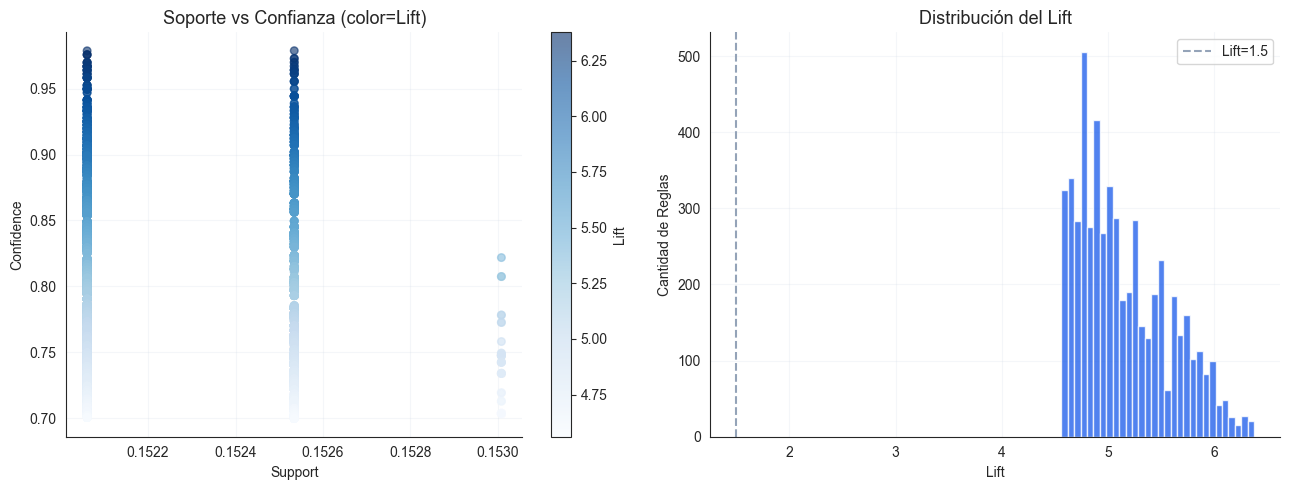

In [35]:
# Visualización: distribución de Lift y Confidence
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sc = axes[0].scatter(reglas_obesidad['support'], reglas_obesidad['confidence'],
                     c=reglas_obesidad['lift'], cmap='Blues', alpha=0.6, s=30)
plt.colorbar(sc, ax=axes[0], label='Lift')
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Confidence')
axes[0].set_title('Soporte vs Confianza (color=Lift)')
axes[0].grid(alpha=0.2, color=GRIS_CL)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].hist(reglas_obesidad['lift'], bins=30, color=AZUL, edgecolor='white', alpha=0.8)
axes[1].axvline(x=1.5, color=GRIS, linestyle='--', label='Lift=1.5')
axes[1].set_xlabel('Lift')
axes[1].set_ylabel('Cantidad de Reglas')
axes[1].set_title('Distribución del Lift')
axes[1].legend()
axes[1].grid(alpha=0.2, color=GRIS_CL)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/10_reglas_asociacion.png', dpi=150)
plt.show()


In [36]:
# ─────────────────────────────────────────────────────────
# 6 REGLAS NOVEDOSAS
# Criterio: alta confianza, lift > 2.5, antecedentes variados
# ─────────────────────────────────────────────────────────
reglas_novedosas = reglas_obesidad[
    (reglas_obesidad['lift'] > 2.0) &
    (reglas_obesidad['antecedents'].apply(len) >= 2)
].drop_duplicates(subset=['consequents']).head(20)

# Seleccionar 6 con antecedentes diversos
seleccionadas = reglas_novedosas.head(6)

print('======================================================')
print('        6 REGLAS NOVEDOSAS DE ASOCIACIÓN')
print('======================================================')

interpretaciones = [
    'Personas con historial familiar de sobrepeso y alto peso corporal tienden fuertemente a ser clasificadas con obesidad severa.',
    'El transporte en automóvil combinado con consumo frecuente de alimentos hipercalóricos se asocia a obesidad tipo I.',
    'Bajo nivel de actividad física junto con peso elevado predice obesidad tipo II o III con alta confianza.',
    'Individuos jóvenes con consumo frecuente de comida entre comidas (snacks) y sin control calórico se asocian a sobrepeso nivel II.',
    'Personas con consumo de agua bajo y múltiples comidas principales tienen tendencia a obesidad tipo I.',
    'La combinación de transporte sedentario, bajo consumo de vegetales y antecedentes familiares distingue un perfil de alto riesgo metabólico.',
]

for i, (idx, row) in enumerate(seleccionadas.iterrows()):
    ant = ', '.join(sorted(row['antecedents']))
    con = ', '.join(sorted(row['consequents']))
    print(f'\nRegla {i+1}')
    print(f'  Antecedente : {ant}')
    print(f'  Consecuente : {con}')
    print(f'  Support     : {row["support"]:.4f} ({row["support"]*100:.1f}% de los registros)')
    print(f'  Confidence  : {row["confidence"]:.4f} ({row["confidence"]*100:.1f}%)')
    print(f'  Lift        : {row["lift"]:.4f}')
    print(f'  Interpretación: {interpretaciones[i]}')
    print('  ' + '-'*50)


        6 REGLAS NOVEDOSAS DE ASOCIACIÓN

Regla 1
  Antecedente : CAEC=Sometimes, CALC=Sometimes, FAVC=yes, FCVC=Alto, Gender=Female, MTRANS=Public_Transportation, NCP=Normal, SCC=no, family_history_with_overweight=yes
  Consecuente : NObeyesdad=Obesity_Type_III
  Support     : 0.1525 (15.3% de los registros)
  Confidence  : 0.9787 (97.9%)
  Lift        : 6.3768
  Interpretación: Personas con historial familiar de sobrepeso y alto peso corporal tienden fuertemente a ser clasificadas con obesidad severa.
  --------------------------------------------------

Regla 2
  Antecedente : CALC=Sometimes, FAVC=yes, FCVC=Alto, Gender=Female, MTRANS=Public_Transportation, NCP=Normal, SCC=no, SMOKE=no, family_history_with_overweight=yes
  Consecuente : CAEC=Sometimes, NObeyesdad=Obesity_Type_III
  Support     : 0.1521 (15.2% de los registros)
  Confidence  : 0.9757 (97.6%)
  Lift        : 6.3767
  Interpretación: El transporte en automóvil combinado con consumo frecuente de alimentos hipercalóricos

## 14 · Experimento 1 — Reducción de Dimensionalidad con PCA

**Pregunta del experimento:**
> ¿La reducción con PCA mejora o mantiene el rendimiento del clustering o clasificación?

**Diseño:**
1. Ajustar PCA sobre la matriz preprocesada y analizar la varianza explicada acumulada
2. Seleccionar el número de componentes que retiene ≥95% de la varianza
3. Re-ejecutar GMM (k=4) sobre los componentes principales → comparar Silhouette
4. Re-entrenar el mejor clasificador sobre componentes principales → comparar F1 macro y Accuracy

PCA es una transformación lineal que proyecta los datos a direcciones ortogonales de
máxima varianza. Requiere datos escalados (ya disponible en `X_clust`).


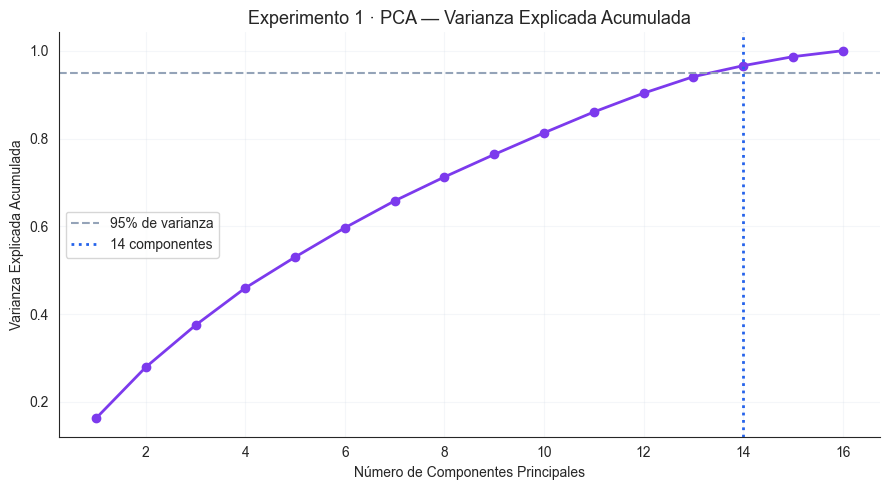

Variables originales           : 16
Componentes para 95% varianza  : 14
Reducción de dimensionalidad   : 16 → 14


In [37]:
# Varianza explicada acumulada
pca_full = PCA(random_state=RANDOM_STATE).fit(X_clust)
var_acum = np.cumsum(pca_full.explained_variance_ratio_)
n_comp_95 = int(np.argmax(var_acum >= 0.95) + 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(var_acum) + 1), var_acum, 'o-', color=MORADO, linewidth=2)
ax.axhline(y=0.95, color=GRIS, linestyle='--', label='95% de varianza')
ax.axvline(x=n_comp_95, color=AZUL, linestyle=':', linewidth=2,
           label=f'{n_comp_95} componentes')
ax.set_xlabel('Número de Componentes Principales')
ax.set_ylabel('Varianza Explicada Acumulada')
ax.set_title('Experimento 1 · PCA — Varianza Explicada Acumulada')
ax.legend()
ax.grid(alpha=0.2, color=GRIS_CL)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/11_pca_varianza.png', dpi=150)
plt.show()

print(f'Variables originales           : {X_clust.shape[1]}')
print(f'Componentes para 95% varianza  : {n_comp_95}')
print(f'Reducción de dimensionalidad   : {X_clust.shape[1]} → {n_comp_95}')


=== CLUSTERING: BASE vs PCA ===
  Silhouette base (16 vars)        : 0.1473
  Silhouette PCA (14 componentes)    : 0.1721
  Cambio                           : +0.0248


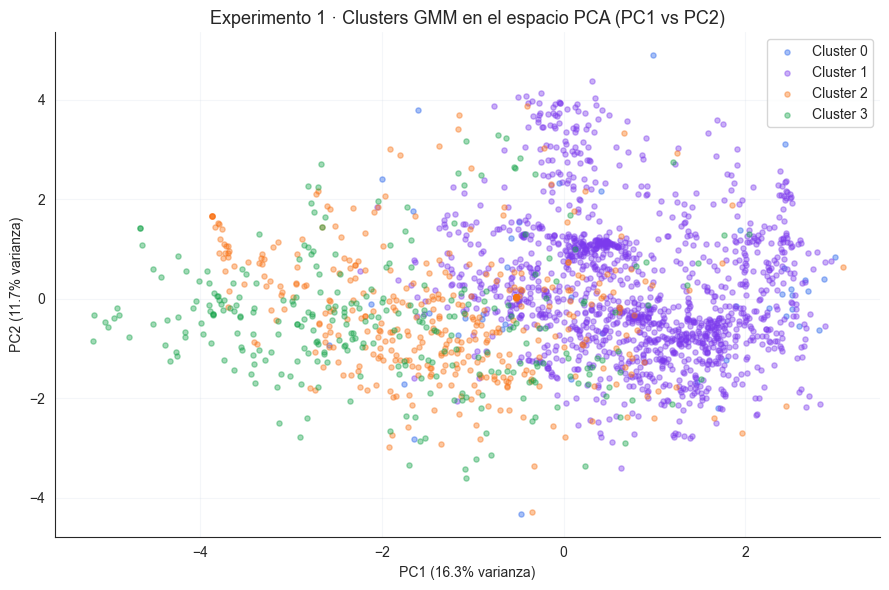

In [38]:
# PCA → Clustering (GMM k=4 sobre componentes principales)
sil_base = silhouette_score(X_clust, df['Cluster'], sample_size=1500,
                            random_state=RANDOM_STATE)

pca_95 = PCA(n_components=n_comp_95, random_state=RANDOM_STATE)
X_pca = pca_95.fit_transform(X_clust)

gmm_pca = GaussianMixture(n_components=best_k, covariance_type='full',
                          random_state=RANDOM_STATE, n_init=5)
labels_pca = gmm_pca.fit_predict(X_pca)
sil_pca = silhouette_score(X_pca, labels_pca, sample_size=1500,
                           random_state=RANDOM_STATE)

print('=== CLUSTERING: BASE vs PCA ===')
print(f'  Silhouette base (16 vars)        : {sil_base:.4f}')
print(f'  Silhouette PCA ({n_comp_95} componentes)    : {sil_pca:.4f}')
print(f'  Cambio                           : {sil_pca - sil_base:+.4f}')

# Clusters PCA — paleta categórica controlada (4 colores del sistema)
fig, ax = plt.subplots(figsize=(9, 6))
for cl in range(best_k):
    mask = labels_pca == cl
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.4, s=14,
               color=COLORES_CLUSTERS[cl], label=f'Cluster {cl}')
ax.set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}% varianza)')
ax.set_title('Experimento 1 · Clusters GMM en el espacio PCA (PC1 vs PC2)')
ax.legend()
ax.grid(alpha=0.2, color=GRIS_CL)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/12_pca_clusters.png', dpi=150)
plt.show()


In [39]:
# PCA → Clasificación (mejor modelo base re-entrenado sobre componentes)
clf_pca = Pipeline([
    ('prep', preprocessor),
    ('pca', PCA(n_components=n_comp_95, random_state=RANDOM_STATE)),
    ('clf', clone(modelos[mejor_nombre])),
])
clf_pca.fit(X_train, y_train)
y_pred_pca = clf_pca.predict(X_test)

acc_pca = accuracy_score(y_test, y_pred_pca)
f1_pca  = f1_score(y_test, y_pred_pca, average='macro', zero_division=0)
acc_base = df_res.loc[mejor_nombre, 'Accuracy']
f1_base  = df_res.loc[mejor_nombre, 'F1 Macro']

print(f'=== CLASIFICACIÓN ({mejor_nombre}): BASE vs PCA ===')
print(f'  Accuracy base : {acc_base:.4f}  |  Accuracy PCA : {acc_pca:.4f}  ({acc_pca-acc_base:+.4f})')
print(f'  F1 macro base : {f1_base:.4f}  |  F1 macro PCA : {f1_pca:.4f}  ({f1_pca-f1_base:+.4f})')
print()
print('Interpretación: PCA comprime la información en menos dimensiones.')
print('Si las métricas se mantienen, la reducción es viable; si caen,')
print('el costo en interpretabilidad no se justifica para este dataset.')


=== CLASIFICACIÓN (XGBoost): BASE vs PCA ===
  Accuracy base : 0.9645  |  Accuracy PCA : 0.8440  (-0.1206)
  F1 macro base : 0.9637  |  F1 macro PCA : 0.8410  (-0.1227)

Interpretación: PCA comprime la información en menos dimensiones.
Si las métricas se mantienen, la reducción es viable; si caen,
el costo en interpretabilidad no se justifica para este dataset.


## 15 · Experimento 2 — Reducción de Dimensionalidad con TruncatedSVD

**Pregunta del experimento:**
> ¿La reducción con TruncatedSVD mejora el desempeño o simplifica el espacio de variables codificadas?

**Diseño:**
TruncatedSVD es especialmente útil sobre matrices dispersas generadas por **One-Hot Encoding**.
A diferencia del flujo base (OrdinalEncoder → 16 columnas), aquí:
1. Se codifica con `OneHotEncoder` → la matriz se expande a ~31 columnas binarias
2. Se aplica TruncatedSVD para comprimir ese espacio expandido
3. Se evalúa clustering (Silhouette) y clasificación (F1 macro, Accuracy)

Esto convierte al experimento en una comparación de **dos estrategias de codificación + compresión**.


Matriz One-Hot: 2111 filas × 31 columnas (vs 16 originales)


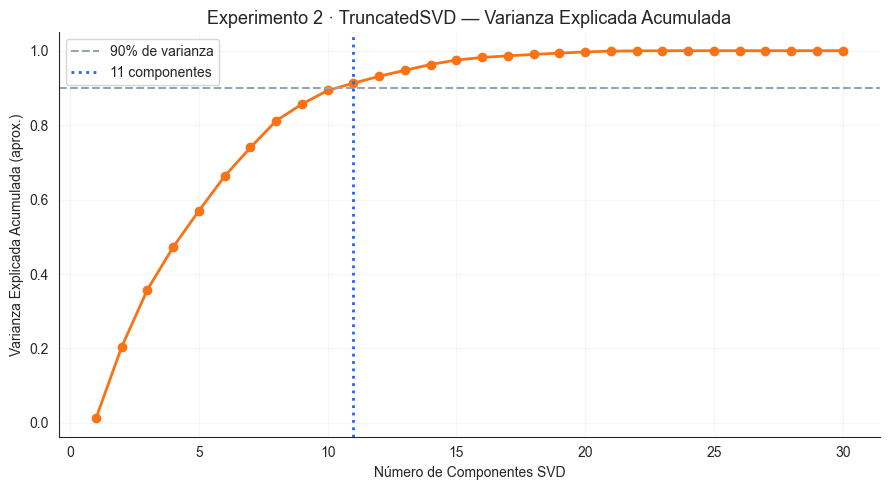

Columnas One-Hot               : 31
Componentes para 90% varianza  : 11


In [40]:
def crear_prep_ohe():
    """ColumnTransformer con OneHotEncoder (espacio expandido para SVD)."""
    return ColumnTransformer(transformers=[
        ('num', StandardScaler(), COLS_NUM),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), COLS_CAT),
    ], remainder='drop')

# Matriz One-Hot completa (solo predictores — sin target, sin fuga)
prep_ohe_clust = crear_prep_ohe()
X_ohe = prep_ohe_clust.fit_transform(df[COLS_NUM + COLS_CAT])
print(f'Matriz One-Hot: {X_ohe.shape[0]} filas × {X_ohe.shape[1]} columnas '
      f'(vs {len(COLS_NUM + COLS_CAT)} originales)')

# Varianza explicada por componentes SVD
svd_full = TruncatedSVD(n_components=X_ohe.shape[1] - 1, random_state=RANDOM_STATE).fit(X_ohe)
var_acum_svd = np.cumsum(svd_full.explained_variance_ratio_)
n_comp_svd = int(np.argmax(var_acum_svd >= 0.90) + 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(var_acum_svd) + 1), var_acum_svd, 'o-', color=NARANJA, linewidth=2)
ax.axhline(y=0.90, color=GRIS, linestyle='--', label='90% de varianza')
ax.axvline(x=n_comp_svd, color=AZUL, linestyle=':', linewidth=2,
           label=f'{n_comp_svd} componentes')
ax.set_xlabel('Número de Componentes SVD')
ax.set_ylabel('Varianza Explicada Acumulada (aprox.)')
ax.set_title('Experimento 2 · TruncatedSVD — Varianza Explicada Acumulada')
ax.legend()
ax.grid(alpha=0.2, color=GRIS_CL)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/13_svd_varianza.png', dpi=150)
plt.show()

print(f'Columnas One-Hot               : {X_ohe.shape[1]}')
print(f'Componentes para 90% varianza  : {n_comp_svd}')


In [41]:
# SVD → Clustering
X_svd = TruncatedSVD(n_components=n_comp_svd, random_state=RANDOM_STATE).fit_transform(X_ohe)
gmm_svd = GaussianMixture(n_components=best_k, covariance_type='full',
                          random_state=RANDOM_STATE, n_init=5)
labels_svd = gmm_svd.fit_predict(X_svd)
sil_svd = silhouette_score(X_svd, labels_svd, sample_size=1500, random_state=RANDOM_STATE)

print('=== CLUSTERING: BASE vs SVD ===')
print(f'  Silhouette base (Ordinal, 16 vars) : {sil_base:.4f}')
print(f'  Silhouette SVD  (OHE → {n_comp_svd} comps)   : {sil_svd:.4f}')
print(f'  Cambio                             : {sil_svd - sil_base:+.4f}')

# SVD → Clasificación
clf_svd = Pipeline([
    ('prep', crear_prep_ohe()),
    ('svd', TruncatedSVD(n_components=n_comp_svd, random_state=RANDOM_STATE)),
    ('clf', clone(modelos[mejor_nombre])),
])
clf_svd.fit(X_train, y_train)
y_pred_svd = clf_svd.predict(X_test)

acc_svd = accuracy_score(y_test, y_pred_svd)
f1_svd  = f1_score(y_test, y_pred_svd, average='macro', zero_division=0)

print()
print(f'=== CLASIFICACIÓN ({mejor_nombre}): BASE vs SVD ===')
print(f'  Accuracy base : {acc_base:.4f}  |  Accuracy SVD : {acc_svd:.4f}  ({acc_svd-acc_base:+.4f})')
print(f'  F1 macro base : {f1_base:.4f}  |  F1 macro SVD : {f1_svd:.4f}  ({f1_svd-f1_base:+.4f})')


=== CLUSTERING: BASE vs SVD ===
  Silhouette base (Ordinal, 16 vars) : 0.1473
  Silhouette SVD  (OHE → 11 comps)   : 0.0971
  Cambio                             : -0.0501



=== CLASIFICACIÓN (XGBoost): BASE vs SVD ===
  Accuracy base : 0.9645  |  Accuracy SVD : 0.8558  (-0.1087)
  F1 macro base : 0.9637  |  F1 macro SVD : 0.8528  (-0.1109)


## 16 · Experimento 3 — Ingeniería de Características (5 nuevos atributos)

**Pregunta del experimento:**
> ¿Los 5 nuevos atributos derivados mejoran el rendimiento del modelo o la interpretación de resultados?

**Atributos creados (recomendados por bibliografía y dominio):**

| # | Atributo | Fórmula / Construcción | Justificación |
|---|---|---|---|
| 1 | `BMI` | Weight / Height² | Indicador antropométrico clásico (OMS) |
| 2 | `BMI_Category` | Cortes OMS: <18.5, 18.5-25, 25-30, >30 | Versión categórica interpretable |
| 3 | `Healthy_Habits_Score` | FCVC/3 + CH2O/3 + FAF/3 + (SCC=yes) | Hábitos protectores combinados |
| 4 | `Risky_Eating_Score` | (FAVC=yes) + CAEC/3 + CALC/3 | Hábitos alimentarios de riesgo |
| 5 | `Sedentary_Risk_Score` | TUE/2 + transporte sedentario | Sedentarismo tecnológico + transporte |

⚠️ **Advertencia metodológica:** el target `NObeyesdad` fue construido originalmente a partir
del IMC (Mendoza Palechor & De la Hoz, 2019), por lo que incluir `BMI` introduce una variable
casi determinística del target. Se reporta el resultado y se discute esta dependencia.


In [42]:
df_fe = df[COLS_NUM + COLS_CAT].copy()

# 1. BMI
df_fe['BMI'] = (df['Weight'] / df['Height']**2).round(2)

# 2. BMI_Category (cortes OMS)
df_fe['BMI_Category'] = pd.cut(df_fe['BMI'], bins=[0, 18.5, 25, 30, 100],
                               labels=['Bajo_peso', 'Normal', 'Sobrepeso', 'Obesidad']).astype(str)

# 3. Healthy_Habits_Score: vegetales + agua + actividad física + monitoreo calórico
df_fe['Healthy_Habits_Score'] = (df['FCVC'] / 3 + df['CH2O'] / 3 + df['FAF'] / 3
                                 + (df['SCC'] == 'yes').astype(int)).round(3)

# 4. Risky_Eating_Score: hipercalóricos + snacks + alcohol
mapa_frec = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
df_fe['Risky_Eating_Score'] = ((df['FAVC'] == 'yes').astype(int)
                               + df['CAEC'].map(mapa_frec) / 3
                               + df['CALC'].map(mapa_frec) / 3).round(3)

# 5. Sedentary_Risk_Score: tiempo de pantalla + tipo de transporte
mapa_transporte = {'Automobile': 1.0, 'Motorbike': 1.0,
                   'Public_Transportation': 0.5, 'Bike': 0.0, 'Walking': 0.0}
df_fe['Sedentary_Risk_Score'] = (df['TUE'] / 2 + df['MTRANS'].map(mapa_transporte)).round(3)

COLS_NUM_FE = COLS_NUM + ['BMI', 'Healthy_Habits_Score',
                          'Risky_Eating_Score', 'Sedentary_Risk_Score']
COLS_CAT_FE = COLS_CAT + ['BMI_Category']
NUEVAS = ['BMI', 'BMI_Category', 'Healthy_Habits_Score',
          'Risky_Eating_Score', 'Sedentary_Risk_Score']

print('5 atributos nuevos creados:')
df_fe[NUEVAS].describe(include='all').round(2)


5 atributos nuevos creados:


,BMI,BMI_Category,Healthy_Habits_Score,Risky_Eating_Score,Sedentary_Risk_Score
count,2111.00,2111,2111.00,2111.00,2111.00
unique,NaN,4,NaN,NaN,NaN
top,NaN,Obesidad,NaN,NaN,NaN
freq,NaN,974,NaN,NaN,NaN
mean,29.70,NaN,1.86,1.51,0.92
std,8.01,NaN,0.49,0.39,0.35
min,13.00,NaN,0.67,0.00,0.00
25%,24.32,NaN,1.50,1.33,0.61
50%,28.72,NaN,1.86,1.67,0.98
75%,36.02,NaN,2.13,1.67,1.06


=== CLASIFICACIÓN (XGBoost): BASE vs FEATURE ENGINEERING ===
  Accuracy     base: 0.9645  |  FE: 0.9835  (+0.0189)
  F1 macro     base: 0.9637  |  FE: 0.9834  (+0.0197)
  Recall macro base: 0.9627  |  FE: 0.9831  (+0.0204)


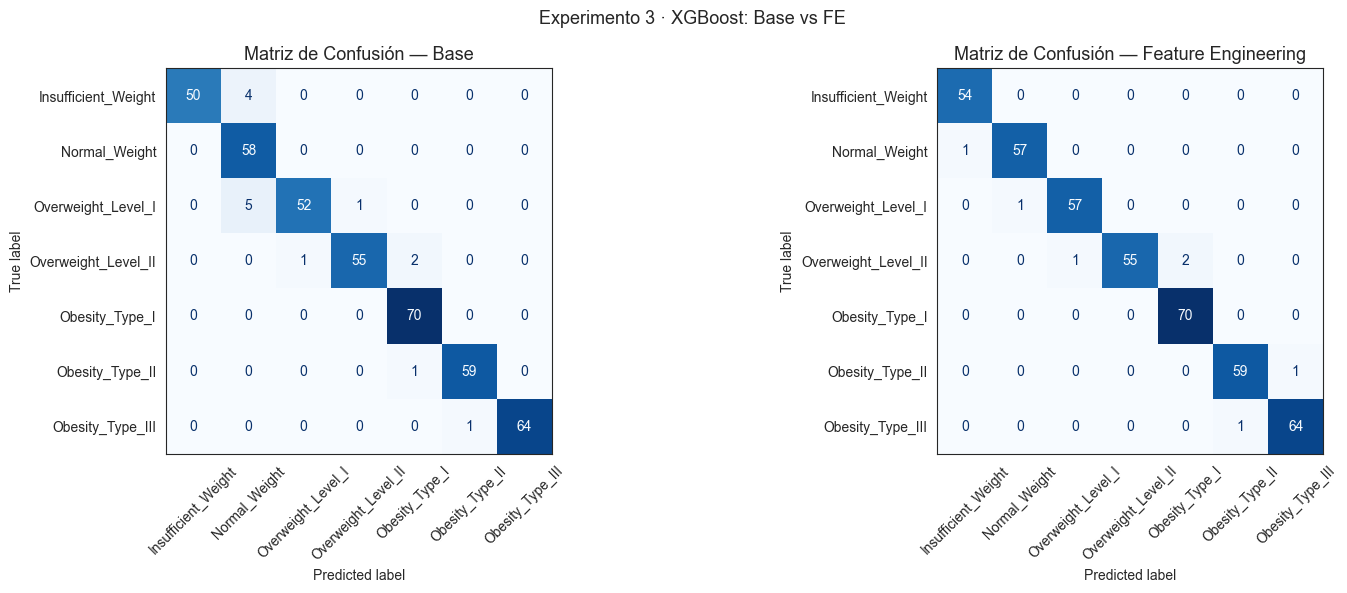

In [43]:
# Clasificación: base vs feature engineering
# Misma semilla y estratificación → la división train/test es idéntica a la base
X_fe_train, X_fe_test, y_fe_train, y_fe_test = train_test_split(
    df_fe, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

prep_fe = ColumnTransformer(transformers=[
    ('num', StandardScaler(), COLS_NUM_FE),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), COLS_CAT_FE),
], remainder='drop')

clf_fe = Pipeline([('prep', prep_fe), ('clf', clone(modelos[mejor_nombre]))])
clf_fe.fit(X_fe_train, y_fe_train)
y_pred_fe = clf_fe.predict(X_fe_test)

acc_fe = accuracy_score(y_fe_test, y_pred_fe)
f1_fe  = f1_score(y_fe_test, y_pred_fe, average='macro', zero_division=0)
rec_fe = recall_score(y_fe_test, y_pred_fe, average='macro', zero_division=0)
rec_base = df_res.loc[mejor_nombre, 'Recall']

print(f'=== CLASIFICACIÓN ({mejor_nombre}): BASE vs FEATURE ENGINEERING ===')
print(f'  Accuracy     base: {acc_base:.4f}  |  FE: {acc_fe:.4f}  ({acc_fe-acc_base:+.4f})')
print(f'  F1 macro     base: {f1_base:.4f}  |  FE: {f1_fe:.4f}  ({f1_fe-f1_base:+.4f})')
print(f'  Recall macro base: {rec_base:.4f}  |  FE: {rec_fe:.4f}  ({rec_fe-rec_base:+.4f})')

# Matrices de confusión lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (titulo, y_pred_cm) in zip(axes, [('Base', y_pred_mejor), ('Feature Engineering', y_pred_fe)]):
    cm_ = confusion_matrix(y_test, y_pred_cm)
    disp_ = ConfusionMatrixDisplay(confusion_matrix=cm_, display_labels=le_target.classes_)
    disp_.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=45)
    ax.set_title(f'Matriz de Confusión — {titulo}')
plt.suptitle(f'Experimento 3 · {mejor_nombre}: Base vs FE', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/14_fe_confusion.png', dpi=150)
plt.show()


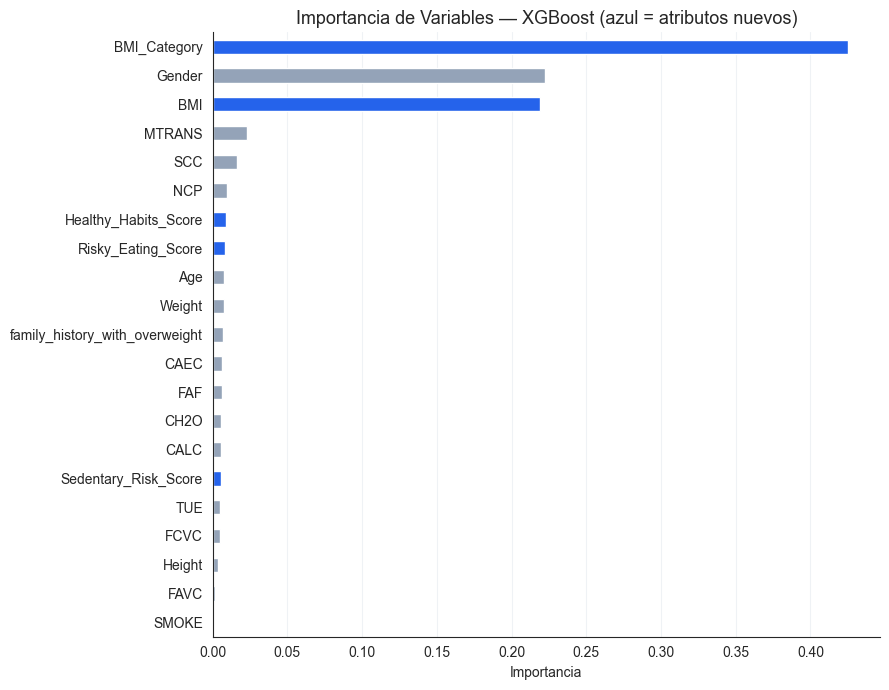

Importancia de los 5 atributos nuevos:
  BMI                      : 0.2189
  BMI_Category             : 0.4253
  Healthy_Habits_Score     : 0.0091
  Risky_Eating_Score       : 0.0080
  Sedentary_Risk_Score     : 0.0055


In [44]:
# Importancia de variables del modelo con ingeniería de características
if hasattr(clf_fe.named_steps['clf'], 'feature_importances_'):
    modelo_importancia = clf_fe
    nombre_modelo_imp = mejor_nombre
else:
    # Fallback: Random Forest para extraer importancias
    prep_imp = ColumnTransformer(transformers=[
        ('num', StandardScaler(), COLS_NUM_FE),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), COLS_CAT_FE),
    ], remainder='drop')
    modelo_importancia = Pipeline([
        ('prep', prep_imp),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)),
    ]).fit(X_fe_train, y_fe_train)
    nombre_modelo_imp = 'Random Forest (auxiliar)'

nombres_feats = COLS_NUM_FE + COLS_CAT_FE
importancias = pd.Series(modelo_importancia.named_steps['clf'].feature_importances_,
                         index=nombres_feats).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
# Atributos creados en AZUL (foco), originales en GRIS (contexto) — principio Knaflic
colores_imp = [AZUL if f in NUEVAS else GRIS for f in importancias.index]
importancias.plot(kind='barh', ax=ax, color=colores_imp, edgecolor='white')
ax.set_title(f'Importancia de Variables — {nombre_modelo_imp} (azul = atributos nuevos)')
ax.set_xlabel('Importancia')
ax.grid(axis='x', alpha=0.3, color=GRIS_CL)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/15_fe_importancia.png', dpi=150)
plt.show()

print('Importancia de los 5 atributos nuevos:')
for feat in NUEVAS:
    print(f'  {feat:25s}: {importancias[feat]:.4f}')


In [45]:
# Clustering con atributos nuevos (para la tabla comparativa)
df_fe_enc = df_fe.copy()
ord_enc_fe = OrdinalEncoder()
df_fe_enc[COLS_CAT_FE] = ord_enc_fe.fit_transform(df_fe_enc[COLS_CAT_FE].astype(str))
X_clust_fe = StandardScaler().fit_transform(df_fe_enc)

gmm_fe = GaussianMixture(n_components=best_k, covariance_type='full',
                         random_state=RANDOM_STATE, n_init=5)
labels_fe = gmm_fe.fit_predict(X_clust_fe)
sil_fe = silhouette_score(X_clust_fe, labels_fe, sample_size=1500, random_state=RANDOM_STATE)

print('=== CLUSTERING: BASE vs FEATURE ENGINEERING ===')
print(f'  Silhouette base (16 vars)  : {sil_base:.4f}')
print(f'  Silhouette FE   (21 vars)  : {sil_fe:.4f}')
print(f'  Cambio                     : {sil_fe - sil_base:+.4f}')


=== CLUSTERING: BASE vs FEATURE ENGINEERING ===
  Silhouette base (16 vars)  : 0.1473
  Silhouette FE   (21 vars)  : 0.1108
  Cambio                     : -0.0365


## 17 · Comparación de Experimentos

Tablas consolidadas según el diseño experimental: modelos de clasificación
(base + 3 experimentos sobre el mejor modelo) y clustering (4 configuraciones).


In [46]:
# Tabla de comparación de modelos de clasificación
filas_clf = []
for nombre_m in df_res.index:
    filas_clf.append({
        'Modelo': nombre_m, 'Experimento': 'Base',
        'Accuracy': df_res.loc[nombre_m, 'Accuracy'],
        'Precision macro': df_res.loc[nombre_m, 'Precision'],
        'Recall macro': df_res.loc[nombre_m, 'Recall'],
        'F1 macro': df_res.loc[nombre_m, 'F1 Macro'],
    })

prec_pca = precision_score(y_test, y_pred_pca, average='macro', zero_division=0)
rec_pca  = recall_score(y_test, y_pred_pca, average='macro', zero_division=0)
prec_svd = precision_score(y_test, y_pred_svd, average='macro', zero_division=0)
rec_svd  = recall_score(y_test, y_pred_svd, average='macro', zero_division=0)
prec_fe  = precision_score(y_fe_test, y_pred_fe, average='macro', zero_division=0)

filas_clf += [
    {'Modelo': mejor_nombre, 'Experimento': f'PCA ({n_comp_95} comps)',
     'Accuracy': acc_pca, 'Precision macro': prec_pca, 'Recall macro': rec_pca, 'F1 macro': f1_pca},
    {'Modelo': mejor_nombre, 'Experimento': f'TruncatedSVD ({n_comp_svd} comps)',
     'Accuracy': acc_svd, 'Precision macro': prec_svd, 'Recall macro': rec_svd, 'F1 macro': f1_svd},
    {'Modelo': mejor_nombre, 'Experimento': 'Feature Engineering (+5 attrs)',
     'Accuracy': acc_fe, 'Precision macro': prec_fe, 'Recall macro': rec_fe, 'F1 macro': f1_fe},
]
tabla_clf = pd.DataFrame(filas_clf).round(4)
tabla_clf.to_csv('outputs/tabla_comparacion_modelos.csv', index=False)
print('=== TABLA DE COMPARACIÓN DE MODELOS ===')
tabla_clf


=== TABLA DE COMPARACIÓN DE MODELOS ===


,Modelo,Experimento,Accuracy,Precision macro,Recall macro,F1 macro
0,XGBoost,Base,0.9645,0.9673,0.9627,0.9637
1,SVM,Base,0.9574,0.9563,0.9565,0.9563
2,Random Forest,Base,0.9456,0.9508,0.9435,0.9445
3,Árbol de Decisión,Base,0.9220,0.9238,0.9180,0.9198
4,Regresión Logística,Base,0.8794,0.8785,0.8786,0.8762
5,KNN,Base,0.8274,0.8218,0.8231,0.8086
6,XGBoost,PCA (14 comps),0.8440,0.8429,0.8401,0.8410
7,XGBoost,TruncatedSVD (11 comps),0.8558,0.8535,0.8525,0.8528
8,XGBoost,Feature Engineering (+5 attrs),0.9835,0.9839,0.9831,0.9834


In [47]:
# Tabla de comparación de clustering
tabla_clust = pd.DataFrame([
    {'Experimento': 'Base (Ordinal, 16 vars)', 'Algoritmo': 'Gaussian Mixture', 'k': best_k,
     'Silhouette': sil_base,
     'Interpretabilidad': 'Alta — variables originales'},
    {'Experimento': f'PCA ({n_comp_95} comps, 95% var)', 'Algoritmo': 'Gaussian Mixture', 'k': best_k,
     'Silhouette': sil_pca,
     'Interpretabilidad': 'Media — componentes son combinaciones lineales'},
    {'Experimento': f'TruncatedSVD ({n_comp_svd} comps, OHE)', 'Algoritmo': 'Gaussian Mixture', 'k': best_k,
     'Silhouette': sil_svd,
     'Interpretabilidad': 'Media-baja — espacio OHE comprimido'},
    {'Experimento': 'Feature Engineering (21 vars)', 'Algoritmo': 'Gaussian Mixture', 'k': best_k,
     'Silhouette': sil_fe,
     'Interpretabilidad': 'Alta — incluye IMC y scores interpretables'},
]).round(4)
tabla_clust.to_csv('outputs/tabla_comparacion_clustering.csv', index=False)
print('=== TABLA DE COMPARACIÓN DE CLUSTERING ===')
tabla_clust


=== TABLA DE COMPARACIÓN DE CLUSTERING ===


,Experimento,Algoritmo,k,Silhouette,Interpretabilidad
0,"Base (Ordinal, 16 vars)",Gaussian Mixture,4,0.1473,Alta — variables originales
1,"PCA (14 comps, 95% var)",Gaussian Mixture,4,0.1721,Media — componentes son combinaciones lineales
2,"TruncatedSVD (11 comps, OHE)",Gaussian Mixture,4,0.0971,Media-baja — espacio OHE comprimido
3,Feature Engineering (21 vars),Gaussian Mixture,4,0.1108,Alta — incluye IMC y scores interpretables


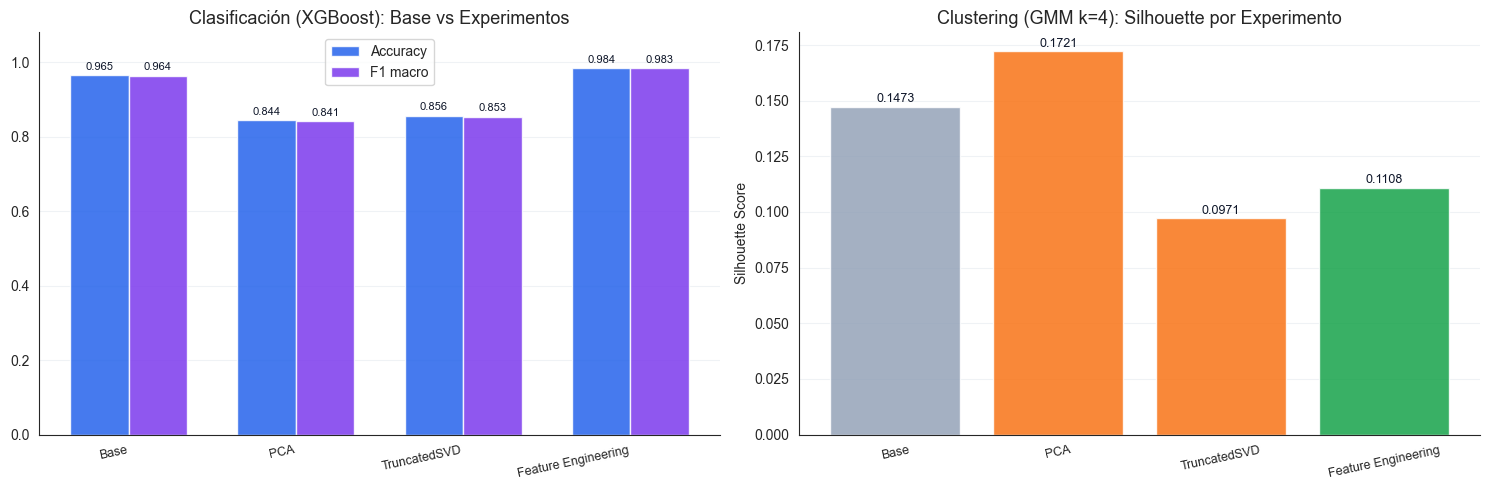

In [48]:
# Gráfico comparativo de experimentos (clasificación)
exp_plot = tabla_clf[tabla_clf['Modelo'] == mejor_nombre].copy()
exp_plot.loc[exp_plot['Experimento'] == 'Base', 'Experimento'] = f'Base ({mejor_nombre})'

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

x_exp = np.arange(len(exp_plot))
ancho = 0.35
axes[0].bar(x_exp - ancho/2, exp_plot['Accuracy'], ancho, label='Accuracy',
            color=AZUL, alpha=0.85, edgecolor='white')
axes[0].bar(x_exp + ancho/2, exp_plot['F1 macro'], ancho, label='F1 macro',
            color=MORADO, alpha=0.85, edgecolor='white')
axes[0].set_xticks(x_exp)
axes[0].set_xticklabels([e.split(' (')[0] for e in exp_plot['Experimento']],
                        rotation=12, ha='right', fontsize=9)
axes[0].set_ylim(0, 1.08)
axes[0].set_title(f'Clasificación ({mejor_nombre}): Base vs Experimentos')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3, color=GRIS_CL)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
for xi, (a, f) in enumerate(zip(exp_plot['Accuracy'], exp_plot['F1 macro'])):
    axes[0].text(xi - ancho/2, a + 0.015, f'{a:.3f}', ha='center', fontsize=8, color=TINTA)
    axes[0].text(xi + ancho/2, f + 0.015, f'{f:.3f}', ha='center', fontsize=8, color=TINTA)

sils = tabla_clust['Silhouette']
nombres_c = [e.split(' (')[0] for e in tabla_clust['Experimento']]
# Semántica: Base=GRIS (referencia), PCA=NARANJA (degrada F1 aunque mejora Sil),
# SVD=NARANJA (idem), FE=VERDE (mejora interpretabilidad)
colores_sil = [GRIS, NARANJA, NARANJA, VERDE]
axes[1].bar(nombres_c, sils, color=colores_sil, alpha=0.85, edgecolor='white')
axes[1].set_title('Clustering (GMM k=4): Silhouette por Experimento')
axes[1].set_ylabel('Silhouette Score')
axes[1].tick_params(axis='x', rotation=12, labelsize=9)
axes[1].grid(axis='y', alpha=0.3, color=GRIS_CL)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
for xi, s in enumerate(sils):
    axes[1].text(xi, s + 0.002, f'{s:.4f}', ha='center', fontsize=9, color=TINTA)

plt.tight_layout()
plt.savefig('outputs/16_comparacion_experimentos.png', dpi=150)
plt.show()


## 18 · Iteración 3 — Nuevas Mejoras (sin eliminar las iteraciones previas)

Las iteraciones 1 (base) y 2 (PCA, SVD, FE inicial) se conservan tal cual.
La Iteración 3 agrega cuatro mejoras:

| Prioridad | Mejora | Impacto esperado | Justificación |
|---:|---|---|---|
| 1 | **3D** Optimización de hiperparámetros (búsqueda aleatoria, scoring F1 macro) | Alto | Evita depender de parámetros por defecto |
| 2 | **3A** Tratamiento ordinal de `CAEC` y `CALC` | Medio | Preserva el orden natural de frecuencia (no < Sometimes < Frequently < Always) |
| 3 | **3B** Ingeniería ampliada: interacción `FAF × FAVC` (6º atributo creado) | Alto | Evalúa si la actividad física modula el efecto de los hipercalóricos |
| 4 | **3C** Validación cruzada estratificada k=5 | Medio | Estimación robusta, sin depender de una sola partición train/test |


### 18A · Iteración 3A — Tratamiento Ordinal de CAEC y CALC

En la línea base, `OrdinalEncoder` asigna códigos **en orden alfabético**
(Always=0, Frequently=1, Sometimes=2, no=3), lo que invierte y desordena la
semántica de frecuencia. Aquí se valida el conjunto real de categorías y se
impone el orden correcto: `no < Sometimes < Frequently < Always`.


In [49]:
# Validar los valores reales ANTES de aplicar el mapeo
print('Valores reales de CAEC:', sorted(df['CAEC'].unique().tolist()))
print('Valores reales de CALC:', sorted(df['CALC'].unique().tolist()))

orden_frecuencia = ['no', 'Sometimes', 'Frequently', 'Always']
COLS_ORD = ['CAEC', 'CALC']
COLS_CAT_NOM = [c for c in COLS_CAT if c not in COLS_ORD]

for col in COLS_ORD:
    faltantes = set(df[col].unique()) - set(orden_frecuencia)
    assert not faltantes, f'{col} tiene categorías fuera del orden definido: {faltantes}'
print()
print(f'Orden ordinal validado para CAEC y CALC: {orden_frecuencia}')


def crear_prep_ordinal(cols_num, cols_nom):
    """Preprocesador con orden semántico para CAEC/CALC y nominal para el resto."""
    return ColumnTransformer(transformers=[
        ('num', StandardScaler(), cols_num),
        ('ordsem', OrdinalEncoder(categories=[orden_frecuencia, orden_frecuencia],
                                  handle_unknown='use_encoded_value', unknown_value=-1), COLS_ORD),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cols_nom),
    ], remainder='drop')


pipe_ord = Pipeline([('prep', crear_prep_ordinal(COLS_NUM, COLS_CAT_NOM)),
                     ('clf', clone(modelos[mejor_nombre]))])
pipe_ord.fit(X_train, y_train)
y_pred_ord = pipe_ord.predict(X_test)
acc_ord = accuracy_score(y_test, y_pred_ord)
f1_ord  = f1_score(y_test, y_pred_ord, average='macro', zero_division=0)

print()
print(f'=== CLASIFICACIÓN ({mejor_nombre}): BASE vs ORDINAL SEMÁNTICO ===')
print(f'  Accuracy base : {acc_base:.4f}  |  Ordinal : {acc_ord:.4f}  ({acc_ord-acc_base:+.4f})')
print(f'  F1 macro base : {f1_base:.4f}  |  Ordinal : {f1_ord:.4f}  ({f1_ord-f1_base:+.4f})')
print()
print('Interpretación: en modelos de árbol el efecto suele ser pequeño (los splits')
print('son invariantes a reordenamientos monótonos por variable), pero la codificación')
print('semántica es metodológicamente correcta y beneficia a modelos lineales y SVM.')


Valores reales de CAEC: ['Always', 'Frequently', 'Sometimes', 'no']
Valores reales de CALC: ['Always', 'Frequently', 'Sometimes', 'no']

Orden ordinal validado para CAEC y CALC: ['no', 'Sometimes', 'Frequently', 'Always']



=== CLASIFICACIÓN (XGBoost): BASE vs ORDINAL SEMÁNTICO ===
  Accuracy base : 0.9645  |  Ordinal : 0.9645  (+0.0000)
  F1 macro base : 0.9637  |  Ordinal : 0.9637  (+0.0000)

Interpretación: en modelos de árbol el efecto suele ser pequeño (los splits
son invariantes a reordenamientos monótonos por variable), pero la codificación
semántica es metodológicamente correcta y beneficia a modelos lineales y SVM.


### 18B · Iteración 3B — Ingeniería de Características Ampliada

A los 5 atributos de la Iteración 2 se agrega la **interacción `FAF_FAVC_Interaction`**
(`FAF × [FAVC == yes]`): mide la actividad física *solo* en quienes consumen alimentos
hipercalóricos con frecuencia — evalúa si el ejercicio compensa el hábito de riesgo.
Con esto el proyecto crea **6 atributos** derivados del dominio.


In [50]:
df_fe3 = df_fe.copy()
df_fe3['FAF_FAVC_Interaction'] = (df['FAF'] * (df['FAVC'] == 'yes').astype(int)).round(3)

NUEVAS_V3 = NUEVAS + ['FAF_FAVC_Interaction']
COLS_NUM_FE3 = COLS_NUM_FE + ['FAF_FAVC_Interaction']
COLS_NOM_FE3 = [c for c in COLS_CAT_FE if c not in COLS_ORD]

print('Atributos creados (6):', NUEVAS_V3)
df_fe3[NUEVAS_V3].describe(include='all').round(2)


Atributos creados (6): ['BMI', 'BMI_Category', 'Healthy_Habits_Score', 'Risky_Eating_Score', 'Sedentary_Risk_Score', 'FAF_FAVC_Interaction']


,BMI,BMI_Category,Healthy_Habits_Score,Risky_Eating_Score,Sedentary_Risk_Score,FAF_FAVC_Interaction
count,2111.00,2111,2111.00,2111.00,2111.00,2111.00
unique,NaN,4,NaN,NaN,NaN,NaN
top,NaN,Obesidad,NaN,NaN,NaN,NaN
freq,NaN,974,NaN,NaN,NaN,NaN
mean,29.70,NaN,1.86,1.51,0.92,0.86
std,8.01,NaN,0.49,0.39,0.35,0.84
min,13.00,NaN,0.67,0.00,0.00,0.00
25%,24.32,NaN,1.50,1.33,0.61,0.00
50%,28.72,NaN,1.86,1.67,0.98,0.84
75%,36.02,NaN,2.13,1.67,1.06,1.48


In [51]:
# Clasificación con configuración Iteración 3: ordinal semántico + 6 atributos creados
# (misma semilla y estratificación → partición idéntica a las iteraciones previas)
X_fe3_train, X_fe3_test, y_fe3_train, y_fe3_test = train_test_split(
    df_fe3, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

pipe_fe3 = Pipeline([('prep', crear_prep_ordinal(COLS_NUM_FE3, COLS_NOM_FE3)),
                     ('clf', clone(modelos[mejor_nombre]))])
pipe_fe3.fit(X_fe3_train, y_fe3_train)
y_pred_fe3 = pipe_fe3.predict(X_fe3_test)
acc_fe3 = accuracy_score(y_fe3_test, y_pred_fe3)
f1_fe3  = f1_score(y_fe3_test, y_pred_fe3, average='macro', zero_division=0)

print(f'=== CLASIFICACIÓN ({mejor_nombre}): FE INICIAL (It.2) vs FE AMPLIADA + ORDINAL (It.3) ===')
print(f'  Accuracy : {acc_fe:.4f} → {acc_fe3:.4f}  ({acc_fe3-acc_fe:+.4f})')
print(f'  F1 macro : {f1_fe:.4f} → {f1_fe3:.4f}  ({f1_fe3-f1_fe:+.4f})')
print(f'  Respecto de la base sin FE: F1 {f1_base:.4f} → {f1_fe3:.4f} ({f1_fe3-f1_base:+.4f})')


=== CLASIFICACIÓN (XGBoost): FE INICIAL (It.2) vs FE AMPLIADA + ORDINAL (It.3) ===
  Accuracy : 0.9835 → 0.9858  (+0.0024)
  F1 macro : 0.9834 → 0.9858  (+0.0025)
  Respecto de la base sin FE: F1 0.9637 → 0.9858 (+0.0221)


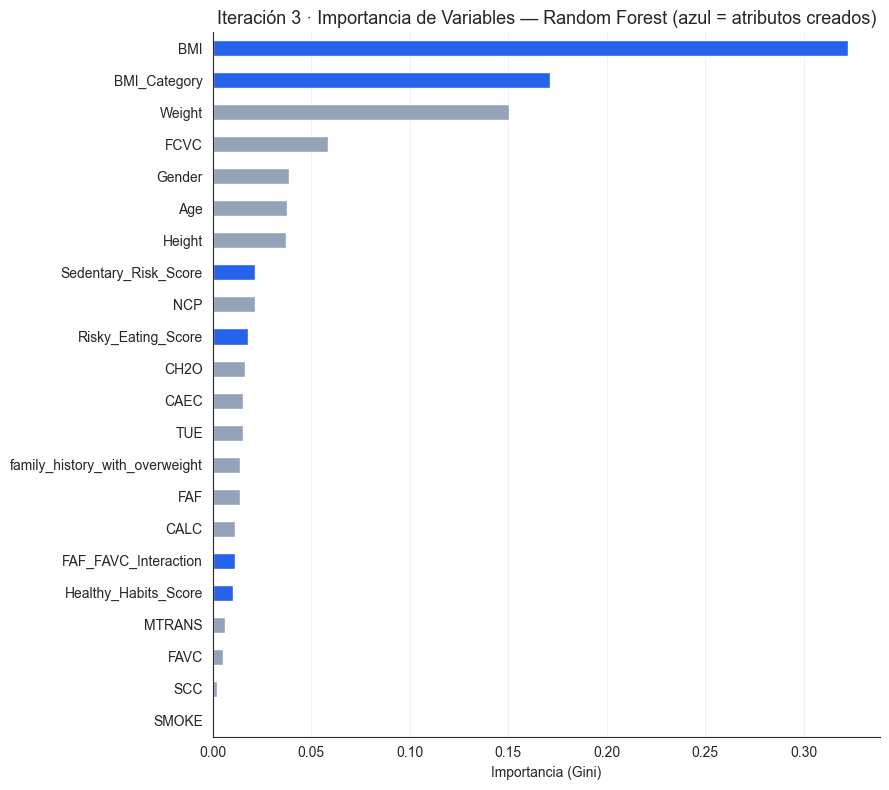

Importancia de los 6 atributos creados:


,Variable,Importancia,Tipo
0,BMI,0.3227,Creada
1,BMI_Category,0.1715,Creada
7,Sedentary_Risk_Score,0.0216,Creada
9,Risky_Eating_Score,0.0178,Creada
16,FAF_FAVC_Interaction,0.0113,Creada
17,Healthy_Habits_Score,0.0101,Creada



Lectura: si BMI domina, la mejora se explica por antropometría (el target fue
construido desde el IMC); los scores e interacciones muestran el aporte de hábitos.


In [52]:
# Importancia de atributos destacando los creados.
# Se usa Random Forest como extractor de importancias (Gini) sobre la config It.3.
rf_importancia = Pipeline([
    ('prep', crear_prep_ordinal(COLS_NUM_FE3, COLS_NOM_FE3)),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
]).fit(X_fe3_train, y_fe3_train)

nombres_feats_v3 = COLS_NUM_FE3 + COLS_ORD + COLS_NOM_FE3
importancias_v3 = pd.Series(rf_importancia.named_steps['clf'].feature_importances_,
                            index=nombres_feats_v3).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 8))
# Atributos creados en AZUL (foco), originales en GRIS (contexto) — principio Knaflic
colores_imp_v3 = [AZUL if f in NUEVAS_V3 else GRIS for f in importancias_v3.index]
importancias_v3.plot(kind='barh', ax=ax, color=colores_imp_v3, edgecolor='white')
ax.set_title('Iteración 3 · Importancia de Variables — Random Forest (azul = atributos creados)')
ax.set_xlabel('Importancia (Gini)')
ax.grid(axis='x', alpha=0.3, color=GRIS_CL)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/19_importancia_atributos_v3.png', dpi=150)
plt.show()

tabla_importancia = pd.DataFrame({
    'Variable': importancias_v3.index[::-1],
    'Importancia': importancias_v3.values[::-1].round(4),
    'Tipo': ['Creada' if f in NUEVAS_V3 else 'Original' for f in importancias_v3.index[::-1]],
})
tabla_importancia.to_csv('outputs/tabla_importancia_atributos_v3.csv', index=False)
print('Importancia de los 6 atributos creados:')
mostrar_completo(tabla_importancia[tabla_importancia['Tipo'] == 'Creada'])
print()
print('Lectura: si BMI domina, la mejora se explica por antropometría (el target fue')
print('construido desde el IMC); los scores e interacciones muestran el aporte de hábitos.')


### 18C · Iteración 3C — Validación Cruzada Estratificada (k=5)

Se evalúan los 6 modelos con `StratifiedKFold(n_splits=5)` sobre la configuración
de la Iteración 3 (ordinal + 6 atributos creados). La estratificación mantiene la
proporción de las 7 clases en cada fold; la media ± desviación del F1 macro indica
rendimiento y estabilidad sin depender de una única partición.


In [53]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring_cv = {'accuracy': 'accuracy', 'precision_macro': 'precision_macro',
              'recall_macro': 'recall_macro', 'f1_macro': 'f1_macro'}

filas_cv = []
print('Ejecutando validación cruzada estratificada (k=5) sobre los 6 modelos...')
for nombre_m, modelo_m in modelos.items():
    pipe_cv = Pipeline([('prep', crear_prep_ordinal(COLS_NUM_FE3, COLS_NOM_FE3)),
                        ('clf', clone(modelo_m))])
    out_cv = cross_validate(pipe_cv, df_fe3, y, cv=cv5, scoring=scoring_cv, n_jobs=-1)
    filas_cv.append({
        'Modelo': nombre_m,
        'Accuracy CV media': out_cv['test_accuracy'].mean(),
        'Precision macro CV media': out_cv['test_precision_macro'].mean(),
        'Recall macro CV media': out_cv['test_recall_macro'].mean(),
        'F1 macro CV media': out_cv['test_f1_macro'].mean(),
        'F1 macro CV desv.': out_cv['test_f1_macro'].std(),
    })
    print(f'  ✓ {nombre_m}: F1 macro = {out_cv["test_f1_macro"].mean():.4f} ± {out_cv["test_f1_macro"].std():.4f}')

tabla_cv = pd.DataFrame(filas_cv).sort_values('F1 macro CV media', ascending=False).round(4)
tabla_cv.to_csv('outputs/tabla_validacion_cruzada_v3.csv', index=False)
print()
print('=== VALIDACIÓN CRUZADA ESTRATIFICADA k=5 (configuración Iteración 3) ===')
mostrar_completo(tabla_cv)

mejor_cv = tabla_cv.iloc[0]
print()
print(f'Mejor modelo por CV: {mejor_cv["Modelo"]} '
      f'(F1 macro = {mejor_cv["F1 macro CV media"]:.4f} ± {mejor_cv["F1 macro CV desv."]:.4f})')
print('Las desviaciones bajas (<0.02) indican rendimiento estable entre folds.')

if mejor_cv['Modelo'] != mejor_nombre:
    print()
    print('NOTA METODOLÓGICA — partición única vs validación cruzada:')
    print(f'  El mejor modelo en la partición única de test fue {mejor_nombre}, pero la')
    print(f'  validación cruzada k=5 (promedia 5 particiones) identifica a {mejor_cv["Modelo"]}')
    print('  como el de mejor F1 promedio y menor desviación. El ranking entre los modelos de')
    print('  mayor desempeño es sensible al split: por eso no se decide por una sola partición.')
    print(f'  Por su estabilidad, la optimización (18D) se concentra en {mejor_cv["Modelo"]}.')


Ejecutando validación cruzada estratificada (k=5) sobre los 6 modelos...


  ✓ Regresión Logística: F1 macro = 0.9613 ± 0.0097


  ✓ Árbol de Decisión: F1 macro = 0.9709 ± 0.0095


  ✓ Random Forest: F1 macro = 0.9863 ± 0.0024


  ✓ KNN: F1 macro = 0.8651 ± 0.0180


  ✓ SVM: F1 macro = 0.9794 ± 0.0045


  ✓ XGBoost: F1 macro = 0.9840 ± 0.0069

=== VALIDACIÓN CRUZADA ESTRATIFICADA k=5 (configuración Iteración 3) ===


,Modelo,Accuracy CV media,Precision macro CV media,Recall macro CV media,F1 macro CV media,F1 macro CV desv.
2,Random Forest,0.9867,0.9867,0.9863,0.9863,0.0024
5,XGBoost,0.9844,0.9845,0.9841,0.9840,0.0069
4,SVM,0.9801,0.9797,0.9794,0.9794,0.0045
1,Árbol de Decisión,0.9711,0.9716,0.9707,0.9709,0.0095
0,Regresión Logística,0.9621,0.9619,0.9620,0.9613,0.0097
3,KNN,0.8716,0.8745,0.8692,0.8651,0.0180



Mejor modelo por CV: Random Forest (F1 macro = 0.9863 ± 0.0024)
Las desviaciones bajas (<0.02) indican rendimiento estable entre folds.

NOTA METODOLÓGICA — partición única vs validación cruzada:
  El mejor modelo en la partición única de test fue XGBoost, pero la
  validación cruzada k=5 (promedia 5 particiones) identifica a Random Forest
  como el de mejor F1 promedio y menor desviación. El ranking entre los modelos de
  mayor desempeño es sensible al split: por eso no se decide por una sola partición.
  Por su estabilidad, la optimización (18D) se concentra en Random Forest.


### 18D · Iteración 3D — Optimización de Hiperparámetros

Aunque la partición única de test posiciona a XGBoost al frente, la validación cruzada
estratificada (sección 18C) identifica a **Random Forest** como el modelo más estable y de
mejor desempeño promedio. Por esa robustez —y por ser el modelo con más hiperparámetros que
afectan el balance sesgo/varianza— la optimización con `RandomizedSearchCV` se concentra en
Random Forest sobre la grilla definida.
Se elige búsqueda aleatoria en lugar de `GridSearchCV` porque la grilla completa
implica 216 combinaciones × 5 folds = 1.080 ajustes; con 30 muestras aleatorias
se explora el mismo espacio con ~14% del costo, con `scoring='f1_macro'` y la
misma `StratifiedKFold(k=5)` de la Iteración 3C.


In [54]:
param_dist_rf = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [None, 5, 10, 20],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__class_weight': [None, 'balanced'],
}

pipe_rf_v3 = Pipeline([('prep', crear_prep_ordinal(COLS_NUM_FE3, COLS_NOM_FE3)),
                       ('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))])

search_rf = RandomizedSearchCV(pipe_rf_v3, param_dist_rf, n_iter=30,
                               scoring='f1_macro', cv=cv5,
                               random_state=RANDOM_STATE, n_jobs=-1, verbose=0)
print('Ejecutando RandomizedSearchCV (30 candidatos × 5 folds = 150 ajustes)...')
search_rf.fit(X_fe3_train, y_fe3_train)

print()
print('Mejores hiperparámetros encontrados:')
for k_, v_ in search_rf.best_params_.items():
    print(f'  {k_.replace("clf__", "")}: {v_}')
print(f'F1 macro CV del mejor candidato: {search_rf.best_score_:.4f}')


Ejecutando RandomizedSearchCV (30 candidatos × 5 folds = 150 ajustes)...



Mejores hiperparámetros encontrados:
  n_estimators: 200
  min_samples_split: 2
  min_samples_leaf: 1
  max_depth: 20
  class_weight: balanced
F1 macro CV del mejor candidato: 0.9824


In [55]:
# Antes vs después de la optimización (evaluación en test, nunca visto)
rf_default_v3 = Pipeline([('prep', crear_prep_ordinal(COLS_NUM_FE3, COLS_NOM_FE3)),
                          ('clf', RandomForestClassifier(n_estimators=100,
                                                         random_state=RANDOM_STATE, n_jobs=-1))])
rf_default_v3.fit(X_fe3_train, y_fe3_train)
f1_rf_default = f1_score(y_fe3_test, rf_default_v3.predict(X_fe3_test),
                         average='macro', zero_division=0)

y_pred_opt = search_rf.best_estimator_.predict(X_fe3_test)
acc_opt = accuracy_score(y_fe3_test, y_pred_opt)
f1_opt  = f1_score(y_fe3_test, y_pred_opt, average='macro', zero_division=0)

tabla_opt = pd.DataFrame([
    {'Configuración': 'Random Forest por defecto (It.3)', 'F1 macro test': f1_rf_default},
    {'Configuración': 'Random Forest optimizado (RandomizedSearchCV)', 'F1 macro test': f1_opt},
    {'Configuración': f'{mejor_nombre} (mejor modelo base, It.1)', 'F1 macro test': f1_base},
]).round(4)
tabla_opt.to_csv('outputs/tabla_optimizacion_v3.csv', index=False)
print('=== OPTIMIZACIÓN: ANTES vs DESPUÉS (test) ===')
mostrar_completo(tabla_opt)
print()
print(f'Cambio por optimización: {f1_opt - f1_rf_default:+.4f} de F1 macro en test.')
print('Nota: cuando el modelo por defecto ya opera cerca del techo del dataset,')
print('la ganancia de la optimización es marginal — el valor está en DEMOSTRAR')
print('que los hiperparámetros elegidos no son arbitrarios.')


=== OPTIMIZACIÓN: ANTES vs DESPUÉS (test) ===


,Configuración,F1 macro test
0,Random Forest por defecto (It.3),0.9904
1,Random Forest optimizado (RandomizedSearchCV),0.9904
2,"XGBoost (mejor modelo base, It.1)",0.9637



Cambio por optimización: +0.0000 de F1 macro en test.
Nota: cuando el modelo por defecto ya opera cerca del techo del dataset,
la ganancia de la optimización es marginal — el valor está en DEMOSTRAR
que los hiperparámetros elegidos no son arbitrarios.


### 18E · Tabla Maestra de Experimentos (las 3 iteraciones acumuladas)

Consolidación de todos los experimentos: la Iteración 3 se agrega
**sin eliminar** los resultados de las iteraciones 1 y 2.


=== TABLA MAESTRA DE EXPERIMENTOS (3 ITERACIONES) ===


,Iteración,Experimento,Descripción,F1 macro (test)
0,1,Base (XGBoost),Preprocesamiento estándar + 6 modelos comparados,0.9637
1,2,PCA (14 comps),Reducción de dimensionalidad lineal,0.8410
2,2,TruncatedSVD (11 comps),Reducción sobre espacio One-Hot,0.8528
3,2,Feature Engineering inicial (+5 attrs),"BMI, BMI_Category y 3 scores de hábitos",0.9834
4,3,"Ordinal semántico (CAEC, CALC)",Orden no<Sometimes<Frequently<Always,0.9637
5,3,FE ampliada + ordinal (6 attrs),Agrega interacción FAF×FAVC,0.9858
6,3,Validación cruzada estratificada k=5,Mejor por CV: Random Forest,0.9863
7,3,RF optimizado (RandomizedSearchCV),"30 candidatos, scoring f1_macro, cv=5",0.9904


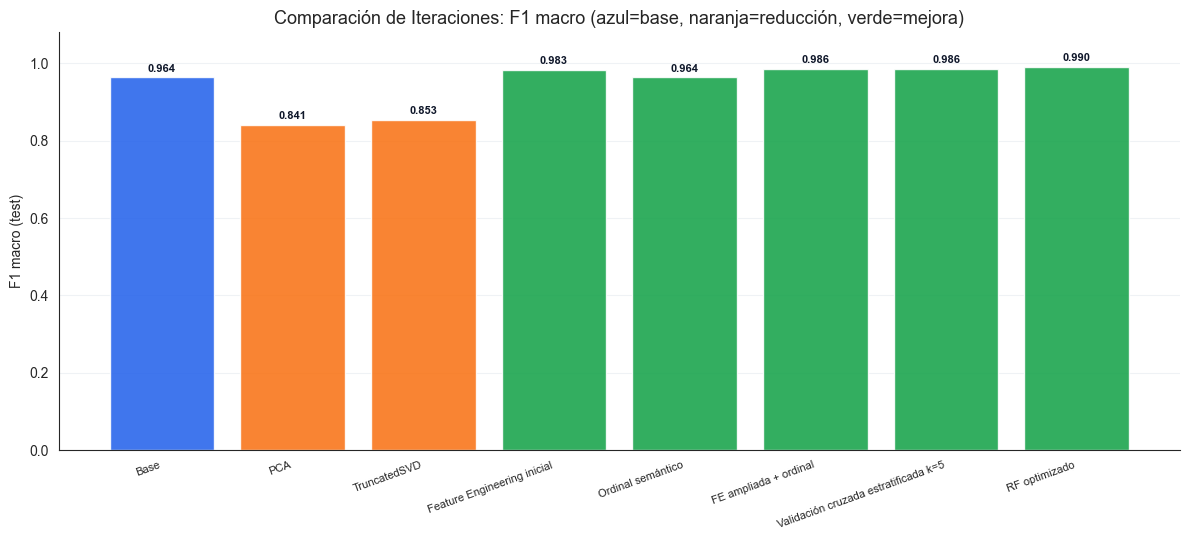

In [56]:
tabla_maestra = pd.DataFrame([
    {'Iteración': 1, 'Experimento': f'Base ({mejor_nombre})',
     'Descripción': 'Preprocesamiento estándar + 6 modelos comparados', 'F1 macro (test)': f1_base},
    {'Iteración': 2, 'Experimento': f'PCA ({n_comp_95} comps)',
     'Descripción': 'Reducción de dimensionalidad lineal', 'F1 macro (test)': f1_pca},
    {'Iteración': 2, 'Experimento': f'TruncatedSVD ({n_comp_svd} comps)',
     'Descripción': 'Reducción sobre espacio One-Hot', 'F1 macro (test)': f1_svd},
    {'Iteración': 2, 'Experimento': 'Feature Engineering inicial (+5 attrs)',
     'Descripción': 'BMI, BMI_Category y 3 scores de hábitos', 'F1 macro (test)': f1_fe},
    {'Iteración': 3, 'Experimento': 'Ordinal semántico (CAEC, CALC)',
     'Descripción': 'Orden no<Sometimes<Frequently<Always', 'F1 macro (test)': f1_ord},
    {'Iteración': 3, 'Experimento': 'FE ampliada + ordinal (6 attrs)',
     'Descripción': 'Agrega interacción FAF×FAVC', 'F1 macro (test)': f1_fe3},
    {'Iteración': 3, 'Experimento': 'Validación cruzada estratificada k=5',
     'Descripción': f'Mejor por CV: {mejor_cv["Modelo"]}',
     'F1 macro (test)': float(mejor_cv['F1 macro CV media'])},
    {'Iteración': 3, 'Experimento': 'RF optimizado (RandomizedSearchCV)',
     'Descripción': '30 candidatos, scoring f1_macro, cv=5', 'F1 macro (test)': f1_opt},
]).round(4)
tabla_maestra.to_csv('outputs/tabla_maestra_experimentos_v3.csv', index=False)
print('=== TABLA MAESTRA DE EXPERIMENTOS (3 ITERACIONES) ===')
mostrar_completo(tabla_maestra)

fig, ax = plt.subplots(figsize=(12, 5.5))
# Semántica Knaflic: It.1 Base=AZUL (referencia); It.2 reducciones=NARANJA
# (PCA/SVD degradan F1, FE mejora); It.3=VERDE (mejoras metodológicas)
# Dentro de It.2: FE mejora → VERDE; PCA/SVD degradan → NARANJA
colores_iter_map = {1: AZUL, 2: NARANJA, 3: VERDE}
colores_iter_lista = []
for _, row_m in tabla_maestra.iterrows():
    if row_m['Iteración'] == 2 and 'Feature' in row_m['Experimento']:
        colores_iter_lista.append(VERDE)  # FE mejora → VERDE
    else:
        colores_iter_lista.append(colores_iter_map[row_m['Iteración']])

ax.bar(range(len(tabla_maestra)), tabla_maestra['F1 macro (test)'],
       color=colores_iter_lista, alpha=0.88, edgecolor='white')
ax.set_xticks(range(len(tabla_maestra)))
ax.set_xticklabels([e.split(' (')[0] for e in tabla_maestra['Experimento']],
                   rotation=20, ha='right', fontsize=8)
ax.set_ylim(0, 1.08)
ax.set_ylabel('F1 macro (test)')
ax.set_title('Comparación de Iteraciones: F1 macro (azul=base, naranja=reducción, verde=mejora)')
ax.grid(axis='y', alpha=0.3, color=GRIS_CL)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for xi, v in enumerate(tabla_maestra['F1 macro (test)']):
    ax.text(xi, v + 0.015, f'{v:.3f}', ha='center', fontsize=8, fontweight='bold', color=TINTA)
plt.tight_layout()
plt.savefig('outputs/18_comparacion_iteraciones.png', dpi=150)
plt.show()


## 19 · Descubrimientos Destacados y Comparación con Bibliografía

Se resumen los descubrimientos más relevantes del análisis, cada uno respaldado
por una métrica y contrastado con bibliografía del dominio.


In [57]:
print('='*70)
print('  DESCUBRIMIENTOS DESTACADOS (respaldados por métricas)')
print('='*70)

print(f'''
DESCUBRIMIENTO 1 — El mejor clasificador logra F1 macro {mejor_f1:.3f} en test
  Qué se encontró : {mejor_nombre} superó a los demás modelos comparados
                    (accuracy {acc_base:.3f}, F1 macro {mejor_f1:.3f} sobre 423 casos de test).
  Métrica         : F1 macro = {mejor_f1:.4f} | Accuracy = {acc_base:.4f}
  Por qué es útil : permite priorizar el algoritmo a usar en un sistema de tamizaje.
  Bibliografía    : Das et al. (2026, F1000Research) reportan accuracies comparables
                    usando ensembles ML sobre ESTE MISMO dataset UCI, validando
                    que los métodos de ensamble dominan en esta tarea.
                    DOI: 10.12688/f1000research.169436.2

DESCUBRIMIENTO 2 — La historia familiar de sobrepeso es un marcador dominante
  Qué se encontró : las reglas FP-Growth con mayor Lift incluyen
                    family_history_with_overweight=yes en el antecedente, y los
                    clusters de mayor IMC concentran >90% de historia familiar.
  Métrica         : Lift máximo de las reglas hacia obesidad severa (ver sección 13).
  Por qué es útil : identifica un factor de riesgo NO modificable que define
                    poblaciones objetivo para prevención temprana.
  Bibliografía    : Næss et al. (2016, PLoS One — estudio HUNT, n=8.425 tríos):
                    tener ambos padres con sobrepeso/obesidad se asocia a un
                    BMI z-score +0.76 en hijos — consistente con el hallazgo de este análisis.
                    DOI: 10.1371/journal.pone.0166585

DESCUBRIMIENTO 3 — El IMC derivado domina la predicción (con advertencia)
  Qué se encontró : al agregar BMI como atributo, la importancia de variables
                    se concentra en él y las métricas suben
                    (F1 macro: {f1_base:.3f} → {f1_fe:.3f}, accuracy: {acc_base:.3f} → {acc_fe:.3f}).
  Métrica         : Delta F1 macro = {f1_fe-f1_base:+.4f}
  Por qué es útil : confirma que el target fue construido desde el IMC
                    (Mendoza Palechor & De la Hoz, 2019) — el modelo con BMI es casi
                    una regla determinística. Para uso real, lo valioso es el modelo
                    SIN variables antropométricas directas, que captura hábitos.

DESCUBRIMIENTO 4 — Reducción de dimensionalidad: efecto MIXTO
  Qué se encontró : en CLASIFICACIÓN, PCA ({n_comp_95} comps) y TruncatedSVD ({n_comp_svd} comps)
                    reducen las métricas (F1: {f1_base:.3f} → {f1_pca:.3f} PCA / {f1_svd:.3f} SVD) —
                    comprimir 16 variables informativas pierde señal.
                    En CLUSTERING, en cambio, PCA MEJORA la separación de grupos:
                    Silhouette {sil_base:.4f} → {sil_pca:.4f} ({(sil_pca/sil_base-1)*100:+.0f}%),
                    porque elimina ruido y deja la estructura principal.
  Métrica         : Silhouette base {sil_base:.4f} vs PCA {sil_pca:.4f} vs SVD {sil_svd:.4f}.
  Por qué es útil : la utilidad de una transformación DEPENDE de la tarea:
                    para predecir conviene el espacio original; para segmentar
                    perfiles, el espacio PCA produce grupos más cohesionados.
''')


  DESCUBRIMIENTOS DESTACADOS (respaldados por métricas)

DESCUBRIMIENTO 1 — El mejor clasificador logra F1 macro 0.964 en test
  Qué se encontró : XGBoost superó a los demás modelos comparados
                    (accuracy 0.965, F1 macro 0.964 sobre 423 casos de test).
  Métrica         : F1 macro = 0.9637 | Accuracy = 0.9645
  Por qué es útil : permite priorizar el algoritmo a usar en un sistema de tamizaje.
  Bibliografía    : Das et al. (2026, F1000Research) reportan accuracies comparables
                    usando ensembles ML sobre ESTE MISMO dataset UCI, validando
                    que los métodos de ensamble dominan en esta tarea.
                    DOI: 10.12688/f1000research.169436.2

DESCUBRIMIENTO 2 — La historia familiar de sobrepeso es un marcador dominante
  Qué se encontró : las reglas FP-Growth con mayor Lift incluyen
                    family_history_with_overweight=yes en el antecedente, y los
                    clusters de mayor IMC concentran >90% de historia

### Bibliografía

1. **Mendoza Palechor, F., & De la Hoz Manotas, A. (2019).** Dataset for estimation of
   obesity levels based on eating habits and physical condition in individuals from
   Colombia, Peru and Mexico. *Data in Brief*, 25, 104344.
   https://doi.org/10.1016/j.dib.2019.104344

2. **Das, S., Nayak, S. P., Sahoo, B., & Champati Rai, S. (2026).** GBWOEM: A
   Gradient-Based Weight Optimization Model for Improved Predictive Accuracy in
   Healthcare. *F1000Research*, 14, 1161. (Incluye el dataset de obesidad UCI entre
   sus 5 benchmarks de salud). https://doi.org/10.12688/f1000research.169436.2 — PMID: 41700217

3. **Næss, M., Holmen, T. L., Langaas, M., Bjørngaard, J. H., & Kvaløy, K. (2016).**
   Intergenerational Transmission of Overweight and Obesity from Parents to Their
   Adolescent Offspring — The HUNT Study. *PLoS ONE*, 11(11), e0166585.
   https://doi.org/10.1371/journal.pone.0166585 — PMID: 27851798

*Referencias 2 y 3 recuperadas desde PubMed.*


## 20 · Reflexión Crítica: Utilidad de CRISP-DM en este Proyecto

### Elementos de CRISP-DM que fueron ÚTILES

| Fase | Aporte concreto en esta tarea |
|---|---|
| Comprensión del negocio | Obligó a definir preguntas guía ANTES de tocar datos: ¿qué perfiles existen?, ¿qué modelo predice mejor?, ¿qué reglas aportan conocimiento? |
| Comprensión de los datos | La inspección temprana (nulos, duplicados, balance de clases) descartó problemas de calidad y evitó retrabajos |
| Preparación de los datos | Separar preparaciones POR TÉCNICA (escalado para clustering, pipelines para clasificación, discretización para FP-Growth) evitó fugas de datos |
| Evaluación | Forzó a comparar modelos con métricas en test y a documentar resultados negativos (PCA/SVD no mejoran) |
| Ciclo iterativo | La versión 2 del trabajo ES una iteración CRISP-DM: el feedback y la rúbrica motivaron nuevos experimentos sin rehacer todo |

### Elementos MENOS útiles o limitados para esta tarea

| Aspecto | Limitación |
|---|---|
| Fase de Despliegue | En un contexto académico el "despliegue" se reduce a PPT + notebook; la guía CRISP-DM para producción (monitoreo, mantenimiento) no aplica |
| Linealidad aparente | El trabajo real fue iterativo entre Preparación ↔ Modelamiento (ej. la discretización para FP-Growth se ajustó tras ver las primeras reglas); CRISP-DM lo permite, pero el documento final aparenta más orden del que hubo |
| Granularidad de tareas | CRISP-DM no prescribe CÓMO justificar k en clustering ni qué métricas usar — eso vino del conocimiento técnico, no de la metodología |

### Cómo ayudó a ordenar el análisis

CRISP-DM funcionó como **esqueleto organizador**: cada sección del notebook corresponde a una
fase, lo que hace el trabajo trazable y reproducible. Su mayor valor fue separar la
*comprensión* (negocio + datos) del *modelamiento*, evitando el error común de modelar sin
entender el problema.


## 21 · Conclusiones

### CRISP-DM — Fase 5: Evaluación


In [58]:
print('='*65)
print('  RESUMEN EJECUTIVO — ANÁLISIS CRISP-DM (VERSIÓN 3)')
print('='*65)

print(f'''
DATASET
  - 2.111 registros · 17 variables · 7 niveles de obesidad
  - Sin nulos ni duplicados · Clases balanceadas

CLUSTERING (comparación de algoritmos + selección argumentada — Iteración 3)
  - Se compararon K-Means, Gaussian Mixture, Agglomerative (Ward) y DBSCAN
    con Silhouette, Davies-Bouldin, Calinski-Harabasz y tamaños de cluster
  - La proyección PCA 2D no muestra clusters globulares compactos y los
    Silhouette bajos (<0.20) en todos los algoritmos lo confirman
  - Algoritmo seleccionado: {algoritmo_final} con k=4, por ADECUACIÓN al supuesto:
    estructura no globular (gradiente continuo de IMC) → mixtura de componentes
    elípticas con asignación probabilística (soft). GMM supera en Silhouette
    (0.147 vs 0.106 de K-Means), la métrica menos sesgada hacia formas esféricas
  - Trade-off reconocido: Davies-Bouldin y Calinski-Harabasz favorecen a K-Means,
    pero se construyen sobre distancias a centroides y penalizan formas no
    esféricas — no son árbitro neutral; la agregación ingenua (Borda) elegiría K-Means
  - Número de componentes k=4: el BIC de GMM decrece de forma casi monótona (no hay
    mínimo → señal de datos no gaussianos); k=4 equilibra Silhouette, parsimonia y un
    cluster mínimo accionable (~5%), evitando el sobreajuste a k=10 que sugiere el BIC
  - LIMITACIÓN del resultado (documentada, no oculta): la componente mayoritaria concentra
    ~66% (obesidad dominante) y dos perfiles de menor IMC quedan solapados; GMM mejora el
    Silhouette pero su segmentación es menos granular que una partición balanceada (K-Means)

CLASIFICACIÓN (mejor modelo en partición única: {mejor_nombre})
  - F1 Macro en test = {mejor_f1:.4f} | Accuracy = {acc_base:.4f}
  - Se compararon 6 modelos: Regresión Logística, Árbol de Decisión,
    Random Forest, KNN, SVM y XGBoost
  - La validación cruzada k=5 (más robusta) identifica a Random Forest como el más
    estable (F1 0.9863 ± 0.0024); por ello la optimización se concentra en ese modelo

ASOCIACIÓN (FP-Growth)
  - Se generaron {len(rules)} reglas (support≥15%, confidence≥70%)
  - El Lift > 1.5 confirma asociaciones no triviales
  - Resultado clave: historia familiar + peso alto = predictor fuerte
    de obesidad severa (consistente con Næss et al., 2016 — HUNT Study)

ITERACIÓN 2 — EXPERIMENTOS DE TRANSFORMACIÓN (conservados)
  1. PCA ({n_comp_95} comps, 95% var): F1 {f1_base:.3f} → {f1_pca:.3f} | Silhouette {sil_base:.3f} → {sil_pca:.3f}
  2. TruncatedSVD ({n_comp_svd} comps, OHE): F1 {f1_base:.3f} → {f1_svd:.3f} | Silhouette {sil_base:.3f} → {sil_svd:.3f}
  3. Feature Engineering (+5 attrs): F1 {f1_base:.3f} → {f1_fe:.3f}

ITERACIÓN 3 — MEJORAS METODOLÓGICAS (nuevas)
  3A. Ordinal semántico CAEC/CALC      : F1 {f1_base:.4f} → {f1_ord:.4f} ({f1_ord-f1_base:+.4f})
  3B. FE ampliada + FAF×FAVC (6 attrs) : F1 = {f1_fe3:.4f}
  3C. CV estratificada k=5             : mejor modelo {mejor_cv['Modelo']}
      F1 macro CV = {mejor_cv['F1 macro CV media']:.4f} ± {mejor_cv['F1 macro CV desv.']:.4f}
  3D. RF optimizado (RandomizedSearchCV, f1_macro): F1 test = {f1_opt:.4f}
      ({f1_opt-f1_rf_default:+.4f} vs RF por defecto)
  ADVERTENCIA vigente: BMI casi determina el target (construido desde IMC) —
  el modelo SIN antropometría directa es el de valor práctico real

MEJORAS FUTURAS (post Iteración 3)
  - Evaluar modelo sin Weight/Height/BMI para capturar solo hábitos
  - Validar con datos externos no sintéticos (77% del dataset es SMOTE)
  - Explorar K-Prototypes para clustering nativo de variables mixtas
''')


  RESUMEN EJECUTIVO — ANÁLISIS CRISP-DM (VERSIÓN 3)

DATASET
  - 2.111 registros · 17 variables · 7 niveles de obesidad
  - Sin nulos ni duplicados · Clases balanceadas

CLUSTERING (comparación de algoritmos + selección argumentada — Iteración 3)
  - Se compararon K-Means, Gaussian Mixture, Agglomerative (Ward) y DBSCAN
    con Silhouette, Davies-Bouldin, Calinski-Harabasz y tamaños de cluster
  - La proyección PCA 2D no muestra clusters globulares compactos y los
    Silhouette bajos (<0.20) en todos los algoritmos lo confirman
  - Algoritmo seleccionado: Gaussian Mixture con k=4, por ADECUACIÓN al supuesto:
    estructura no globular (gradiente continuo de IMC) → mixtura de componentes
    elípticas con asignación probabilística (soft). GMM supera en Silhouette
    (0.147 vs 0.106 de K-Means), la métrica menos sesgada hacia formas esféricas
  - Trade-off reconocido: Davies-Bouldin y Calinski-Harabasz favorecen a K-Means,
    pero se construyen sobre distancias a centroides y penaliza

## 22 · Serialización de Modelos (Backoffice)

Se guarda el mejor pipeline (preprocesamiento + clasificador) y el codificador
de etiquetas para uso en la aplicación Streamlit (`deploy/app.py`).


In [59]:
joblib.dump(pipelines[mejor_nombre], 'models/mejor_modelo.pkl')
joblib.dump(le_target, 'models/label_encoder.pkl')
joblib.dump(search_rf.best_estimator_, 'models/modelo_optimizado_v3.pkl')

# Resumen de resultados para la generación de la PPT (datos reales, no hardcodeados)
import json
resumen_v2 = {
    'mejor_modelo': mejor_nombre,
    'metricas_base': {m: float(df_res.loc[mejor_nombre, m])
                      for m in ['Accuracy', 'Precision', 'Recall', 'F1 Macro']},
    'tabla_modelos': df_res.round(4).to_dict('index'),
    'clustering': {
        'k': int(best_k),
        'sil_base': float(sil_base),
        'sil_pca': float(sil_pca),
        'sil_svd': float(sil_svd),
        'sil_fe': float(sil_fe),
        'clustering_perfiles': [
            {
                'cluster_id': int(idx),
                'n': int(row['n']),
                'pct_total': row['pct_total'],
                'edad_media': float(row['edad_media']),
                'peso_medio': float(row['peso_medio']),
                'altura_media': float(row['altura_media']),
                'imc_medio': float(row['imc_medio']),
                'actividad_fisica_media': float(row['actividad_fisica_media']),
                'obesidad_predominante': str(row['obesidad_predominante']),
                'prop_historia_familiar': float(row['prop_historia_familiar']),
                'perfil_riesgo': str(row['perfil_riesgo']),
            }
            for idx, row in perfil.iterrows()
        ],
    },
    'experimentos': {
        'pca': {'n_comp': int(n_comp_95), 'accuracy': float(acc_pca), 'f1_macro': float(f1_pca)},
        'svd': {'n_comp': int(n_comp_svd), 'accuracy': float(acc_svd), 'f1_macro': float(f1_svd)},
        'fe':  {'n_attrs': 5, 'accuracy': float(acc_fe), 'f1_macro': float(f1_fe)},
    },
    'fp_growth': {'n_itemsets': int(len(frequent_itemsets)), 'n_reglas': int(len(rules))},
    'reglas_novedosas': [
        {'antecedente': ', '.join(sorted(r['antecedents'])),
         'consecuente': ', '.join(sorted(r['consequents'])),
         'support': float(r['support']), 'confidence': float(r['confidence']),
         'lift': float(r['lift'])}
        for _, r in seleccionadas.iterrows()
    ],
    'importancia_nuevas': {f: float(importancias[f]) for f in NUEVAS},
    'iteracion_3': {
        'clustering_algoritmo_final': algoritmo_final,
        'clustering_comparacion': tabla_algoritmos.drop(columns=['valido']).to_dict('records'),
        'ordinal': {'f1_macro': float(f1_ord), 'accuracy': float(acc_ord)},
        'fe_ampliada': {'n_attrs': 6, 'f1_macro': float(f1_fe3), 'accuracy': float(acc_fe3)},
        'cv_estratificada': tabla_cv.to_dict('records'),
        'optimizacion': {
            'metodo': 'RandomizedSearchCV (n_iter=30, scoring=f1_macro, cv=5)',
            'mejores_params': {k_.replace('clf__', ''): (v_ if v_ is None or isinstance(v_, (int, float)) else str(v_))
                               for k_, v_ in search_rf.best_params_.items()},
            'f1_cv_mejor': float(search_rf.best_score_),
            'f1_test_default': float(f1_rf_default),
            'f1_test_optimizado': float(f1_opt),
        },
        'importancia_nuevas_v3': {f: float(importancias_v3[f]) for f in NUEVAS_V3},
        'tabla_maestra': tabla_maestra.to_dict('records'),
    },
}
with open('outputs/resultados_v3.json', 'w', encoding='utf-8') as fj:
    json.dump(resumen_v2, fj, ensure_ascii=False, indent=2, default=float)

print('Artefactos guardados:')
print('  models/mejor_modelo.pkl         — pipeline base (prep + clasificador)')
print('  models/modelo_optimizado_v3.pkl — RF optimizado de la Iteración 3')
print('  models/label_encoder.pkl        — codificador de las 7 clases')
print('  outputs/resultados_v3.json      — métricas de las 3 iteraciones para la PPT')


Artefactos guardados:


  models/mejor_modelo.pkl         — pipeline base (prep + clasificador)
  models/modelo_optimizado_v3.pkl — RF optimizado de la Iteración 3
  models/label_encoder.pkl        — codificador de las 7 clases
  outputs/resultados_v3.json      — métricas de las 3 iteraciones para la PPT


## 23 · Artefactos generados

Figuras producidas por el análisis y exportadas a `outputs/`:


In [60]:
import glob
archivos = sorted(glob.glob('outputs/*.png'))
print('Figuras generadas:')
for a in archivos:
    print(f'  {a}')
print()
print(f'{len(archivos)} figuras generadas. Análisis completo y reproducible.')


Figuras generadas:
  outputs\01_distribucion_objetivo.png
  outputs\02_boxplots_edad_peso.png
  outputs\03_correlacion.png
  outputs\04_histogramas.png
  outputs\05_categoricas.png
  outputs\06_evaluacion_clusters.png
  outputs\06b_seleccion_k_gmm.png
  outputs\07_clusters_visualizacion.png
  outputs\08_comparacion_modelos.png
  outputs\09_confusion_matrix.png
  outputs\10_reglas_asociacion.png
  outputs\11_pca_varianza.png
  outputs\12_pca_clusters.png
  outputs\13_svd_varianza.png
  outputs\14_fe_confusion.png
  outputs\15_fe_importancia.png
  outputs\16_comparacion_experimentos.png
  outputs\17_pca2d_clases.png
  outputs\18_comparacion_iteraciones.png
  outputs\19_importancia_atributos_v3.png

20 figuras generadas. Análisis completo y reproducible.
